# Modelos para series de tiempo: CNN y CNN-LSTM

A continuación se presentan dos ejemplos completos para el pronóstico de series de tiempo usando redes neuronales:
- CNN (Red Neuronal Convolucional)
- CNN-LSTM (Modelo Híbrido)

Ambos ejemplos usan datos descargados de Yahoo Finance, pero puedes adaptar el código para tus propios datos si lo deseas.


2026-05-12 11:09:18.464014: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Index(['date', 'anxiety', 'depression', 'online_therapy', 'panic_attacks',
       'stress', 'anxiety_diff', 'online_diff'],
      dtype='str')
         date  anxiety  depression  online_therapy  panic_attacks  stress  \
0  2004-03-01       41          73               0             41      35   
1  2004-04-01       45          84               0             50      40   
2  2004-05-01       44          83               0             34      43   
3  2004-06-01       44          79               0             41      30   
4  2004-07-01       46          74               0             44      28   

   anxiety_diff  online_diff  
0          -2.0          0.0  
1           4.0          0.0  
2          -1.0          0.0  
3           0.0          0.0  
4           2.0          0.0  
Shape datos: (262, 1)


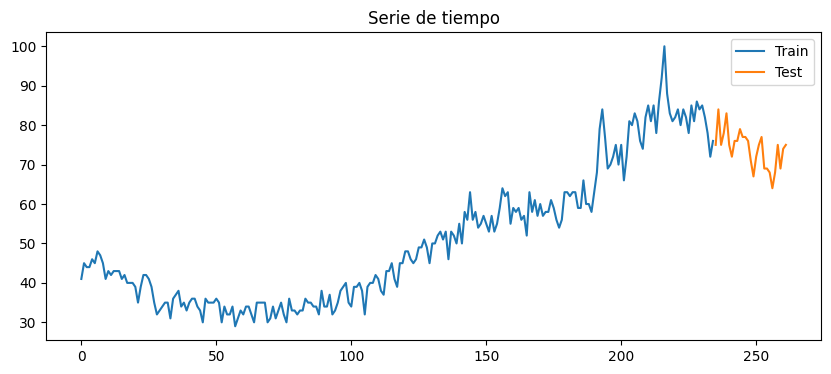

In [1]:
# --- 1. Importación de librerías y carga de datos locales ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, LSTM, GRU, TimeDistributed, Input
import warnings
warnings.filterwarnings("ignore")

# Cargar datos locales
ruta = "mental_health_spain_final.csv"
df = pd.read_csv(ruta)
print(df.columns)
print(df.head())

# Selecciona la columna de interés (por ejemplo, 'anxiety')
serie = df['anxiety'].values
serie = np.array(serie)[:, np.newaxis]
print('Shape datos:', serie.shape)

# --- 2. División en train y test ---
time_test = 0.10
train = serie[: int(len(serie) * (1 - time_test))]
test = serie[int(len(serie) * (1 - time_test)) :]

plt.figure(figsize=(10, 4))
plt.plot(train, label='Train')
plt.plot(range(len(train), len(train)+len(test)), test, label='Test')
plt.legend()
plt.title('Serie de tiempo')
plt.show()


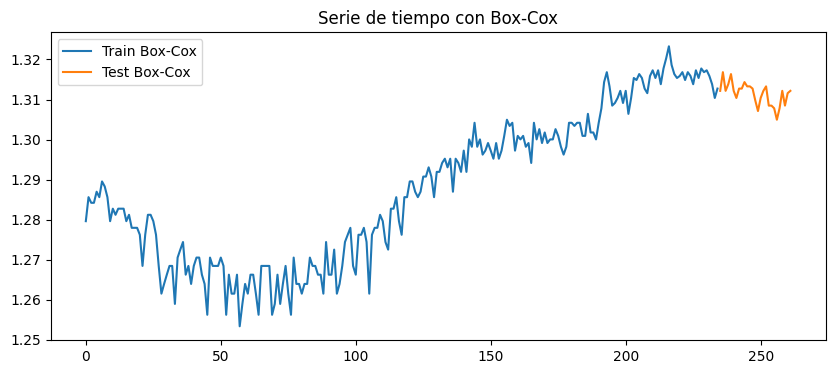

In [12]:
#Grafica con Transformacibión de Box-Cox
# --- 3. Transformación de Box-Cox ---
train_boxcox, lambda_ = boxcox(train.flatten())
test_boxcox = boxcox(test.flatten(), lmbda=lambda_) 
plt.figure(figsize=(10, 4))
plt.plot(train_boxcox, label='Train Box-Cox')
plt.plot(range(len(train_boxcox), len(train_boxcox)+len(test_boxcox)), test_boxcox, label='Test Box-Cox')
plt.legend()
plt.title('Serie de tiempo con Box-Cox')
plt.show()


In [13]:
# --- 3. Función para conformar el dataset secuencial ---
def split_sequence(sequence, time_step):
    X, y = list(), list()
    for i in range(len(sequence)):
        end_ix = i + time_step
        if end_ix > len(sequence) - 1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


### ¿Cómo funciona split_sequence y el parámetro time_step?

La función `split_sequence` toma una serie de números (por ejemplo, valores de una serie temporal) y la divide en ventanas deslizantes de longitud `time_step`.

- Cada ventana de `time_step` valores consecutivos se usa como una muestra de entrada (X) para la red.
- El valor inmediatamente siguiente a esa ventana es la salida (y) que la red debe predecir.

Por ejemplo, si tienes la secuencia:

    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Y usas `time_step = 5`, la función generará:

- X: [ [1,2,3,4,5], [2,3,4,5,6], [3,4,5,6,7], [4,5,6,7,8], [5,6,7,8,9], [6,7,8,9,10], [7,8,9,10,11] ]
- y: [6, 7, 8, 9, 10, 11, 12]

Así, cada muestra de entrada X contiene 5 valores consecutivos, y la red aprende a predecir el siguiente valor (y) usando esos 5 valores previos.

**En resumen:**
- Cada muestra de entrada a la red es una ventana de `time_step` valores.
- La salida esperada es el valor siguiente a esa ventana.
- Esto permite a la red aprender patrones temporales y predecir el próximo valor de la serie.


**¿Qué pasa con el valor y (la salida)?**

- El valor y nunca se usa como entrada para la red neuronal.
- Cada ventana X (por ejemplo, 5 valores) se pasa como entrada a la red.
- La red produce una predicción (y_pred) para esa ventana.
- El valor y real solo se usa para comparar con la predicción y calcular el error (loss), que sirve para ajustar los pesos de la red durante el entrenamiento.
- Así, la red aprende a predecir el siguiente valor de la serie usando solo los valores anteriores, sin ver el valor real y como input.

**Ejemplo visual:**

Supón que tienes los datos:

    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Con time_step = 4, la función genera:

- X = [ [1,2,3,4], [2,3,4,5], [3,4,5,6], [4,5,6,7], [5,6,7,8], [6,7,8,9] ]
- y = [5, 6, 7, 8, 9, 10]

Durante el entrenamiento:
- Cada X (por ejemplo, [1,2,3,4]) entra a la red y la red predice un valor (y_pred).
- El valor y real (5) se usa solo para calcular el error y ajustar la red, pero nunca entra como input.

Esto es igual para cualquier arquitectura (capas, neuronas, etc.): la salida real solo se usa para comparar, nunca como entrada.

## Modelo 1: CNN para series de tiempo

X_train: (231, 4, 1) X_test: (23, 4, 1)
RMSE CNN: 4.4779817418505266


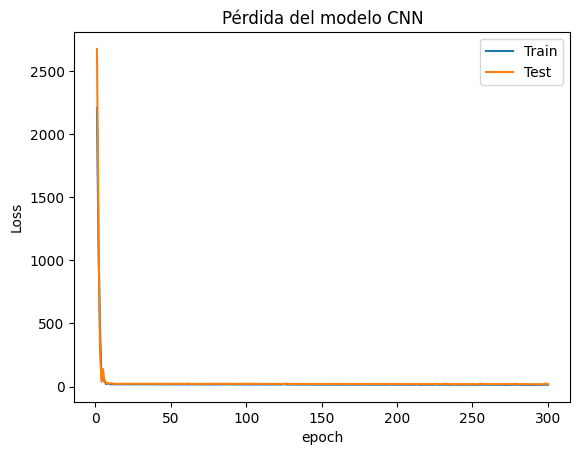

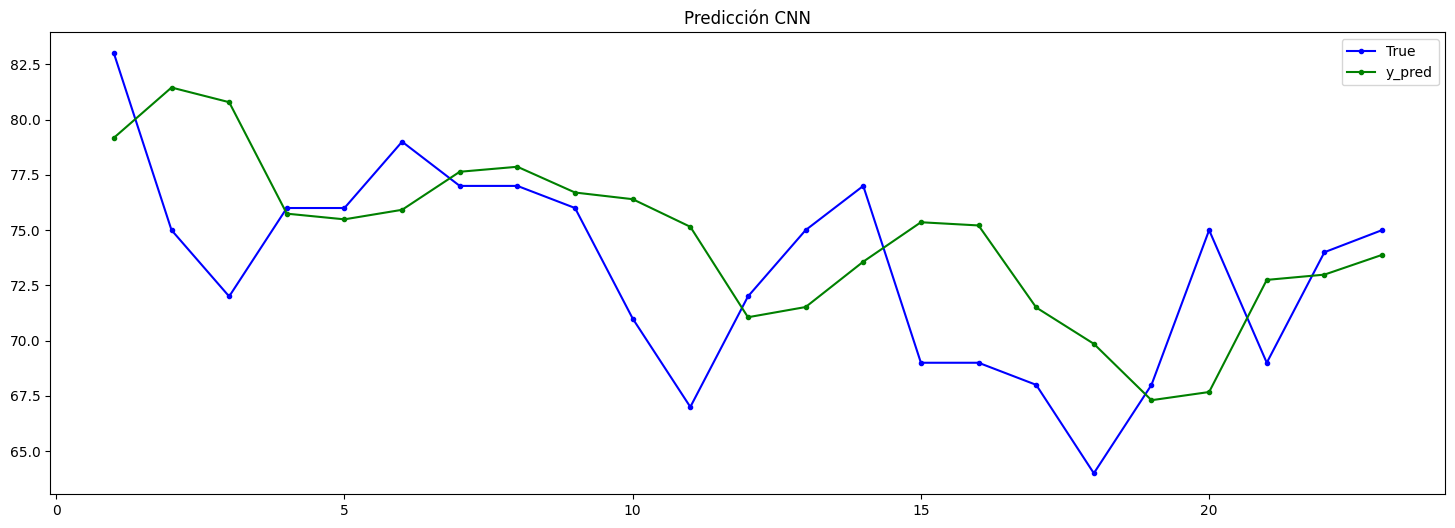

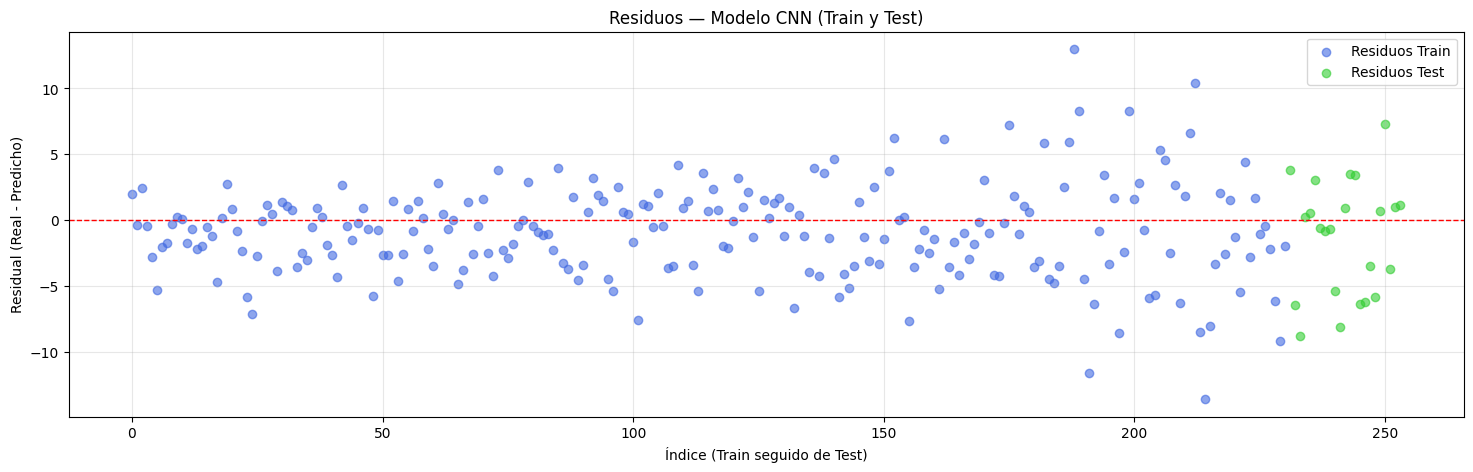

--- Métricas (espacio escalado) ---
RMSE Test: 4.477982
MAE  Test: 3.579868
R²   Test: -0.029672


In [14]:
# --- Preparar datos para CNN ---
time_step = 4
X_train, y_train = split_sequence(train, time_step)
X_test, y_test = split_sequence(test, time_step)
print('X_train:', X_train.shape, 'X_test:', X_test.shape)

# --- Definir y entrenar modelo CNN ---
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten

model_cnn = Sequential()
model_cnn.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(time_step, 1)))
model_cnn.add(Conv1D(filters=64, kernel_size=2, activation='relu'))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Flatten())
model_cnn.add(Dense(20, activation='relu'))
model_cnn.add(Dense(1))
model_cnn.compile(optimizer='Adam', loss='mse')
history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=300,
    batch_size=32,
    verbose=0    
)

# --- Evaluación y predicción CNN ---
rmse_cnn = model_cnn.evaluate(X_test, y_test, verbose=0) ** 0.5
print('RMSE CNN:', rmse_cnn)

plt.plot(range(1, len(history_cnn.epoch) + 1), history_cnn.history["loss"], label="Train")
plt.plot(range(1, len(history_cnn.epoch) + 1), history_cnn.history["val_loss"], label="Test")
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.legend()
plt.title('Pérdida del modelo CNN')
plt.show()

# Predicción
y_pred_cnn = model_cnn.predict(X_test, verbose=0)
plt.figure(figsize=(18, 6))
plt.plot(range(1, len(X_test) + 1), test[time_step:, :], color="b", marker=".", linestyle="-", label="True")
plt.plot(range(1, len(X_test) + 1), y_pred_cnn, color="g", marker=".", linestyle="-", label="y_pred")
plt.legend()
plt.title('Predicción CNN')
plt.show()

# --- Métricas adicionales y gráfico de residuos ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Gráfico de residuos conjunto (Train y Test) ---
residuos_test = y_test.flatten() - y_pred_cnn.flatten()
residuos_train = y_train.flatten() - model_cnn.predict(X_train, verbose=0).flatten()
plt.figure(figsize=(18, 5))
plt.scatter(range(len(residuos_train)), residuos_train, alpha=0.6, label="Residuos Train", color="royalblue")
plt.scatter(range(len(residuos_train), len(residuos_train) + len(residuos_test)), residuos_test, alpha=0.6, label="Residuos Test", color="limegreen")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Residuos — Modelo CNN (Train y Test)")
plt.xlabel("Índice (Train seguido de Test)")
plt.ylabel("Residual (Real - Predicho)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Cálculo de métricas en espacio escalado
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_cnn))
mae_test = mean_absolute_error(y_test, y_pred_cnn)
r2_test = r2_score(y_test, y_pred_cnn)
print("--- Métricas (espacio escalado) ---")
print(f"RMSE Test: {rmse_test:.6f}")
print(f"MAE  Test: {mae_test:.6f}")
print(f"R²   Test: {r2_test:.6f}")


### ¿Cómo funcionan los filtros en una capa Conv1D?

Cuando usas una capa `Conv1D` con, por ejemplo, 64 filtros, lo que ocurre es lo siguiente:

- **A cada ventana de entrada (por ejemplo, 5 valores si `time_step=5`) le aplican 64 filtros diferentes.**
- **Cada filtro es como una "lupa" que recorre la secuencia buscando un patrón específico:** puede ser una subida, una bajada, una oscilación, un pico, etc.
- **Cada filtro tiene sus propios pesos y aprende a detectar un tipo de patrón diferente.**
- **El resultado:** para cada posición de la ventana, obtienes 64 valores de salida (uno por filtro), que representan la "respuesta" de cada filtro ante esa parte de la secuencia.

#### Ejemplo concreto:
Supón que tienes una base de datos con 250 datos y defines `time_step = 5`.
- La función de preparación de datos genera 245 ventanas deslizantes (de 5 valores cada una).
- Cada ventana es una muestra de entrada para la red.
- Cuando estas ventanas entran a la capa Conv1D con 64 filtros:
    - **Cada ventana es procesada por los 64 filtros, cada uno con sus propios pesos.**
    - El resultado es que, para cada ventana, obtienes 64 "respuestas" (una por filtro).

#### Analogía visual:
Imagina que tienes una imagen y le aplicas diferentes filtros (como los de Instagram): uno resalta los bordes, otro los colores, otro las texturas. En series de tiempo, cada filtro de la CNN aprende a detectar un patrón temporal distinto.

#### Resumen:
- **Más filtros = más tipos de patrones puede aprender la red.**
- **Cada filtro actúa de forma independiente y aprende a detectar algo diferente en la secuencia.**
- **La salida de la capa Conv1D es una combinación de todas las respuestas de los filtros, que luego se usan en las siguientes capas para hacer la predicción.

### Flujo completo de datos en una CNN 1D para series de tiempo
A continuación, se explica de forma intuitiva y paso a paso cómo fluye la información desde la entrada hasta la predicción final en una red convolucional 1D (Conv1D):

1. **Entrada:**
   - Se toma una ventana de datos de la serie temporal (por ejemplo, `[3, 5, 7, 9, 11]`).

2. **Capa Conv1D:**
   - Cada filtro (kernel) se desliza sobre la ventana.
   - En cada posición, multiplica los valores de la ventana por los pesos del filtro y suma el resultado.
   - Ejemplo con kernel_size=2 y filtro [2, -1]:
     - [3, 5] → (3×2) + (5×-1) = 1
     - [5, 7] → (5×2) + (7×-1) = 3
     - [7, 9] → (7×2) + (9×-1) = 5
     - [9, 11] → (9×2) + (11×-1) = 7
   - Así, cada filtro genera una secuencia de resultados.
   - Si hay varios filtros, cada uno genera su propia secuencia.

3. **¿Cómo detectan patrones los filtros?**
   - Los filtros empiezan con pesos aleatorios.
   - Durante el entrenamiento, la red ajusta los pesos para que cada filtro responda fuerte a un patrón útil para la predicción.
   - Por ejemplo:
     - Un filtro con pesos `[1, -2, 1]` responde fuerte a un pico (bajo, alto, bajo).
     - Un filtro con pesos `[1, 0, -1]` responde fuerte a subidas o bajadas.
   - Así, cada filtro termina especializándose en detectar subidas, bajadas, picos, valles, repeticiones, etc.
   - Si la ventana de datos se parece al patrón del filtro, la suma será alta; si no, será baja o negativa.

4. **Función de activación:**
   - A cada valor de la secuencia se le aplica una función de activación (por ejemplo, ReLU: deja pasar solo los valores positivos).

5. **MaxPooling1D:**
   - Toma grupos consecutivos de valores (por ejemplo, de 2 en 2) y se queda solo con el mayor de cada grupo.
   - Ejemplo: si la secuencia es [1, 3, 5, 7, 9] y pool_size=2:
     - [1, 3] → 3
     - [5, 7] → 7
     - [9] → 9 (si queda uno solo, se toma tal cual)
   - Resultado después de MaxPooling: [3, 7, 9]

6. **(Opcional) Más capas Conv1D y MaxPooling:**
   - Se pueden repetir los pasos anteriores para extraer patrones más complejos.

7. **Flatten:**
   - Convierte la secuencia (matriz) resultante en un vector plano para poder conectarla a las capas densas.

8. **Capas Dense (densas):**
   - El vector plano se pasa a una o varias capas densas, donde cada neurona aprende combinaciones de los patrones detectados.

9. **Capa de salida:**
   - Finalmente, la última capa produce la predicción (por ejemplo, el siguiente valor de la serie temporal).

**Resumen visual:**
Entrada → Conv1D (multiplica y suma) → Activación → MaxPooling (elige máximos) → (más Conv1D/Pooling) → Flatten → Dense → Predicción

## Modelo 2: CNN-LSTM para series de tiempo

X_train_cnnlstm: (229, 2, 3, 1) X_test_cnnlstm: (21, 2, 3, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 2, 3, 32)       │            96 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 2, 3, 32)       │         2,080 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 2, 1, 32)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 2, 32)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 25)             │         5,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,002 (31.26 KB)

 Trainable params: 8,002 (31.26 KB)

 Non-trainable params: 0 (0.00 B)

RMSE CNN-LSTM: 3.671379802670454


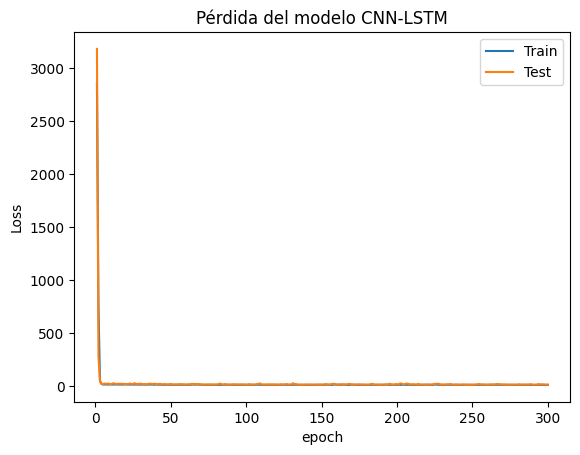

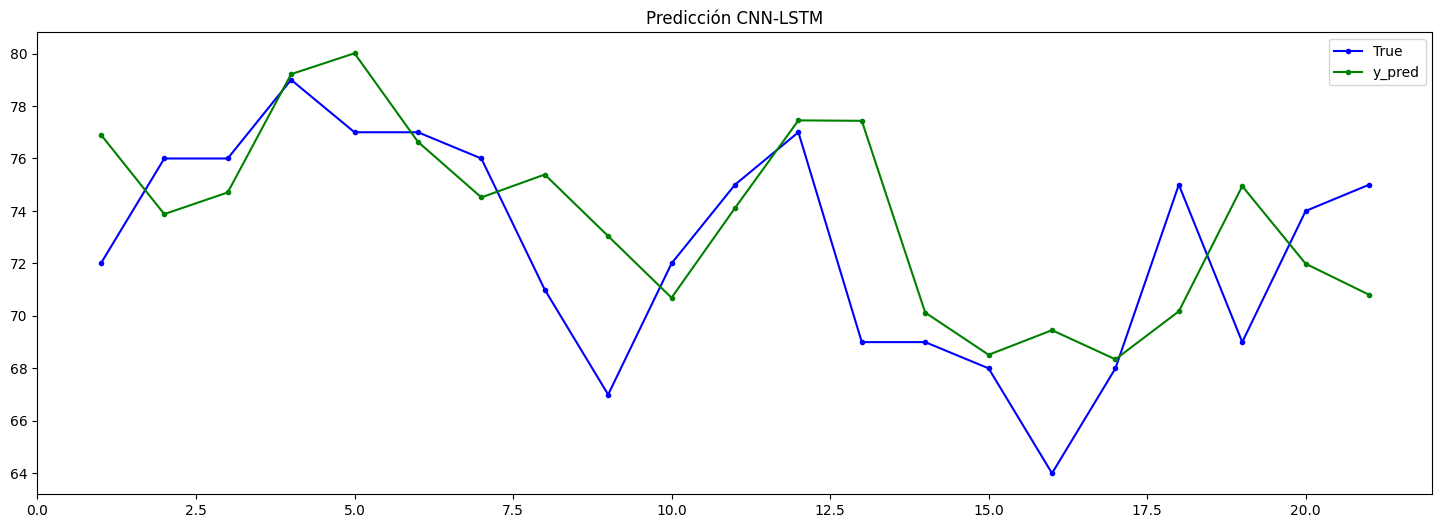

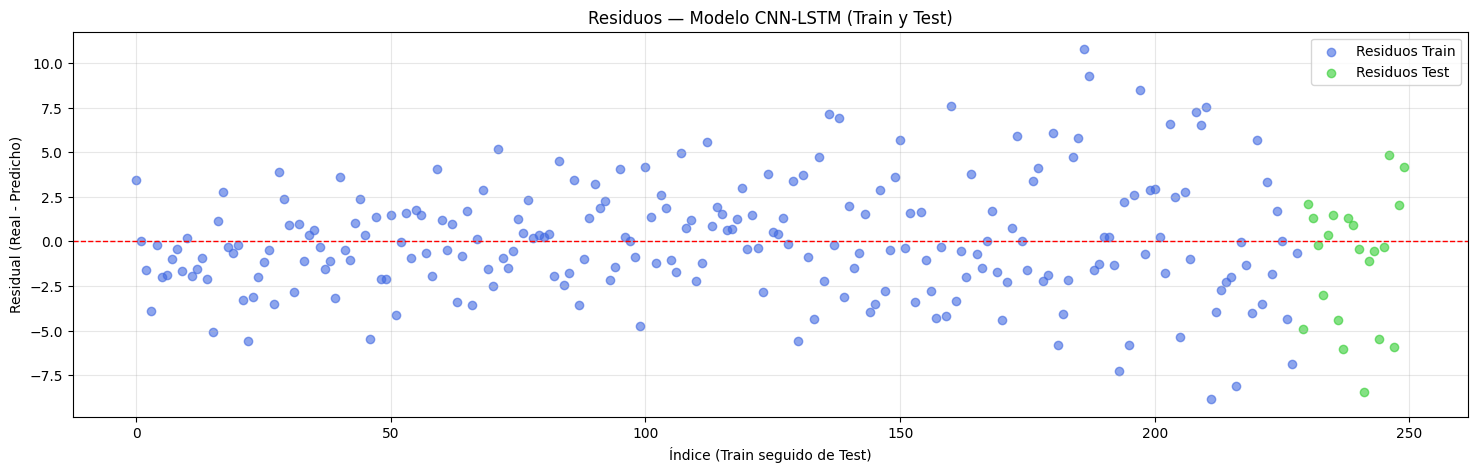

--- Métricas (espacio escalado) ---
RMSE Test: 3.671380
MAE  Test: 2.825603
R²   Test: 0.173950


In [15]:
# --- 7. Preparar datos para CNN-LSTM ---
time_step = 6
X_train, y_train = split_sequence(train, time_step)
X_test, y_test = split_sequence(test, time_step)

subsequences = 2
timesteps = X_train.shape[1] // subsequences
X_train_cnnlstm = X_train.reshape((X_train.shape[0], subsequences, timesteps, 1))
X_test_cnnlstm = X_test.reshape((X_test.shape[0], subsequences, timesteps, 1))
print('X_train_cnnlstm:', X_train_cnnlstm.shape, 'X_test_cnnlstm:', X_test_cnnlstm.shape)

# --- 8. Definir y entrenar modelo CNN-LSTM ---
from keras.layers import TimeDistributed, LSTM, Input

model_cnnlstm = Sequential()
# Definir entrada con (subsequences, timesteps, features)
model_cnnlstm.add(Input(shape=(subsequences, timesteps, 1)))
# Usar padding='same' para evitar reducir demasiado la dimensión temporal
model_cnnlstm.add(TimeDistributed(Conv1D(filters=32, kernel_size=2, activation='relu', padding='same', strides=1)))
model_cnnlstm.add(TimeDistributed(Conv1D(filters=32, kernel_size=2, activation='relu', padding='same', strides=1)))
model_cnnlstm.add(TimeDistributed(MaxPooling1D(pool_size=2)))
model_cnnlstm.add(TimeDistributed(Flatten()))
model_cnnlstm.add(LSTM(25, activation='relu'))
model_cnnlstm.add(Dense(1))
model_cnnlstm.compile(optimizer='Adam', loss='mse')
# Mostrar resumen para verificar shapes intermedias
model_cnnlstm.summary()
history_cnnlstm = model_cnnlstm.fit(
    X_train_cnnlstm, y_train,
    validation_data=(X_test_cnnlstm, y_test),
    epochs=300,
    batch_size=16,
    verbose=0,
 )
# --- Evaluación y predicción CNN ---
rmse_cnnlstm = model_cnnlstm.evaluate(X_test_cnnlstm, y_test, verbose=0) ** 0.5
print('RMSE CNN-LSTM:', rmse_cnnlstm)

plt.plot(range(1, len(history_cnnlstm.epoch) + 1), history_cnnlstm.history["loss"], label="Train")
plt.plot(range(1, len(history_cnnlstm.epoch) + 1), history_cnnlstm.history["val_loss"], label="Test")
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.legend()
plt.title('Pérdida del modelo CNN-LSTM')
plt.show()

# Predicción
y_pred_cnnlstm = model_cnnlstm.predict(X_test_cnnlstm, verbose=0)
plt.figure(figsize=(18, 6))
plt.plot(range(1, len(X_test_cnnlstm) + 1), test[time_step:, :], color="b", marker=".", linestyle="-", label="True")
plt.plot(range(1, len(X_test_cnnlstm) + 1), y_pred_cnnlstm, color="g", marker=".", linestyle="-", label="y_pred")
plt.legend()
plt.title('Predicción CNN-LSTM')
plt.show()

# --- Métricas adicionales y gráfico de residuos ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# --- Gráfico de residuos conjunto (Train y Test) ---
residuos_test = y_test.flatten() - y_pred_cnnlstm.flatten()
residuos_train = y_train.flatten() - model_cnnlstm.predict(X_train_cnnlstm, verbose=0).flatten()
plt.figure(figsize=(18, 5))
plt.scatter(range(len(residuos_train)), residuos_train, alpha=0.6, label="Residuos Train", color="royalblue")
plt.scatter(range(len(residuos_train), len(residuos_train) + len(residuos_test)), residuos_test, alpha=0.6, label="Residuos Test", color="limegreen")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Residuos — Modelo CNN-LSTM (Train y Test)")
plt.xlabel("Índice (Train seguido de Test)")
plt.ylabel("Residual (Real - Predicho)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Cálculo de métricas en espacio escalado
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_cnnlstm))
mae_test = mean_absolute_error(y_test, y_pred_cnnlstm)
r2_test = r2_score(y_test, y_pred_cnnlstm)
print("--- Métricas (espacio escalado) ---")
print(f"RMSE Test: {rmse_test:.6f}")
print(f"MAE  Test: {mae_test:.6f}")
print(f"R²   Test: {r2_test:.6f}")

# Optimización de Hiperparámetros en Redes Neuronales para Series de Tiempo: CNN

In [30]:
def entrenar_modelos_cnn_ts(
    train_scaled,
    test_scaled,
    train_index,
    test_index,
    prepare_data,
    lags,
    cantidad_modelos,
    filters,
    kernel_size,
    pool_size,
    n_conv_layers,
    strides,
    padding,
    post_cnn_type,
    post_cnn_units,
    n_post_cnn_layers,
    activation_conv,
    activation_post,
    learning_rate,
    batch_size,
    optimizer,
    Dropout_rate,
    epochs,
    loss="mse",
    scaler=None,
    transformacion=None,
    lambda_bc=None,
    guardar_modelos=True,
    graficar_loss=True,
    graficar_ajuste=True,
    graficar_residuales=True,
):
    """Entrena múltiples redes CNN para series de tiempo."""

    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    # -------------------------------------------------
    # Funciones auxiliares
    # -------------------------------------------------
    def seleccionar(param):
        if isinstance(param, list):
            return np.random.choice(param).item()
        return param

    def invertir_a_escala_original(valores):
        resultado = valores.copy().flatten()
        if scaler is not None:
            resultado = scaler.inverse_transform(
                resultado.reshape(-1, 1)
            ).flatten()
        if transformacion == "log":
            resultado = np.exp(resultado)
        elif transformacion == "boxcox":
            if lambda_bc is None:
                raise ValueError(
                    "Se requiere lambda_bc para invertir Box-Cox."
                )
            if np.isclose(lambda_bc, 0.0):
                resultado = np.exp(resultado)
            else:
                resultado = np.power(lambda_bc * resultado + 1.0, 1.0 / lambda_bc)
        elif transformacion is not None:
            raise ValueError(
                f"Transformación '{transformacion}' no soportada. "
                "Use None, 'log' o 'boxcox'."
            )
        return resultado

    def invertir_solo_scaler(valores):
        resultado = valores.copy().flatten()
        if scaler is not None:
            resultado = scaler.inverse_transform(
                resultado.reshape(-1, 1)
            ).flatten()
        return resultado

    opt_dict = {
        "Adam": optimizers.Adam,
        "RMSprop": optimizers.RMSprop,
        "SGD": optimizers.SGD,
        "Adagrad": optimizers.Adagrad,
        "Adadelta": optimizers.Adadelta,
        "Adamax": optimizers.Adamax,
        "Nadam": optimizers.Nadam,
        "Ftrl": optimizers.Ftrl,
    }

    post_layer_dict = {
        "LSTM": LSTM,
        "GRU": GRU,
    }

    if transformacion == "boxcox" and lambda_bc is None:
        raise ValueError(
            "Debe proporcionar lambda_bc cuando transformacion='boxcox'."
        )

    max_lag_permitido = min(len(train_scaled), len(test_scaled)) - 1
    if max_lag_permitido < 1:
        raise ValueError("La serie es demasiado corta para crear lags.")

    if isinstance(lags, list):
        lags = [lag for lag in lags if lag <= max_lag_permitido]
        if not lags:
            raise ValueError(
                f"Todos los lags propuestos son mayores que el máximo permitido ({max_lag_permitido})."
            )

    hay_inversion = (scaler is not None) or (transformacion is not None)
    resultados = []
    predicciones = {}

    for i in range(cantidad_modelos):
        lags_i = int(seleccionar(lags))
        filters_i = int(seleccionar(filters))
        kernel_size_i = int(seleccionar(kernel_size))
        pool_size_i = int(seleccionar(pool_size))
        n_conv_i = int(seleccionar(n_conv_layers))
        strides_i = int(seleccionar(strides))
        padding_i = seleccionar(padding)
        post_type_i = seleccionar(post_cnn_type)
        post_units_i = int(seleccionar(post_cnn_units))
        n_post_i = int(seleccionar(n_post_cnn_layers))
        act_conv_i = seleccionar(activation_conv)
        act_post_i = seleccionar(activation_post)
        lr_i = seleccionar(learning_rate)
        batch_size_i = int(seleccionar(batch_size))
        optimizer_i = seleccionar(optimizer)
        dropout_i = seleccionar(Dropout_rate)
        epochs_i = int(seleccionar(epochs))

        print(f"\n{'='*60}")
        print(f"Modelo {i+1}/{cantidad_modelos} — CNN + {post_type_i}")
        print(f"{'='*60}")
        print(f"  Lags: {lags_i}, Epochs: {epochs_i}")

        X_train, y_train = prepare_data(train_scaled, lags_i)
        X_test, y_test = prepare_data(test_scaled, lags_i)

        if len(X_train) == 0 or len(X_test) == 0:
            print(
                f"  ✗ Se omite este modelo porque lags={lags_i} deja "
                f"vacío train o test (train={len(train_scaled)}, test={len(test_scaled)})."
            )
            continue

        X_train = X_train.reshape(X_train.shape[0], lags_i, 1)
        X_test = X_test.reshape(X_test.shape[0], lags_i, 1)

        model = Sequential()
        model.add(Input(shape=(lags_i, 1)))

        for _ in range(n_conv_i):
            current_kernel = min(kernel_size_i, lags_i)
            model.add(
                Conv1D(
                    filters=filters_i,
                    kernel_size=current_kernel,
                    activation=act_conv_i,
                    padding=padding_i,
                    strides=strides_i,
                )
            )
            if dropout_i > 0:
                model.add(Dropout(dropout_i))

        model.add(MaxPooling1D(pool_size=pool_size_i))

        if post_type_i in post_layer_dict:
            RecurrentLayer = post_layer_dict[post_type_i]
            for layer_idx in range(n_post_i):
                model.add(
                    RecurrentLayer(
                        post_units_i,
                        activation=act_post_i,
                        return_sequences=layer_idx < (n_post_i - 1),
                    )
                )
                if dropout_i > 0:
                    model.add(Dropout(dropout_i))
        elif post_type_i == "Dense":
            model.add(Flatten())
            for _ in range(n_post_i):
                model.add(Dense(post_units_i, activation=act_post_i))
                if dropout_i > 0:
                    model.add(Dropout(dropout_i))
        else:
            raise ValueError(
                f"post_cnn_type '{post_type_i}' no soportado. Use 'LSTM', 'GRU' o 'Dense'."
            )

        model.add(Dense(1))

        if optimizer_i not in opt_dict:
            raise ValueError(f"Optimizador '{optimizer_i}' no soportado.")
        opt = opt_dict[optimizer_i](learning_rate=lr_i)

        model.compile(loss=loss, optimizer=opt)

        try:
            history = model.fit(
                X_train,
                y_train,
                validation_data=(X_test, y_test),
                epochs=epochs_i,
                batch_size=batch_size_i,
                verbose=0,
            )
        except Exception as e:
            print(f"\n  ✗ Error al entrenar modelo {i+1}: {e}")
            print("  Saltando este modelo...")
            continue

        y_train_pred = model.predict(X_train, verbose=0).flatten()
        y_test_pred = model.predict(X_test, verbose=0).flatten()

        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)

        idx_train = train_index[lags_i:]
        idx_test = test_index[lags_i:]

        print(f"  RMSE Train: {rmse_train:.6f} | Test: {rmse_test:.6f}")
        print(f"  R² Train: {r2_train:.6f} | Test: {r2_test:.6f}")

        y_train_inv = y_test_inv = y_train_pred_inv = y_test_pred_inv = None
        rmse_train_inv = rmse_test_inv = r2_train_inv = r2_test_inv = None

        if hay_inversion:
            y_train_inv = invertir_a_escala_original(y_train)
            y_test_inv = invertir_a_escala_original(y_test)
            y_train_pred_inv = invertir_a_escala_original(y_train_pred)
            y_test_pred_inv = invertir_a_escala_original(y_test_pred)
            rmse_train_inv = np.sqrt(
                mean_squared_error(y_train_inv, y_train_pred_inv)
            )
            rmse_test_inv = np.sqrt(
                mean_squared_error(y_test_inv, y_test_pred_inv)
            )
            r2_train_inv = r2_score(y_train_inv, y_train_pred_inv)
            r2_test_inv = r2_score(y_test_inv, y_test_pred_inv)

        if graficar_loss:
            plt.figure(figsize=(10, 4))
            plt.plot(history.history["loss"], label="Loss (Train)")
            plt.plot(history.history["val_loss"], label="Val Loss (Test)")
            plt.title(f"Loss — Modelo {i+1} (CNN + {post_type_i})")
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

        if graficar_ajuste:
            if hay_inversion:
                plt.figure(figsize=(15, 5))
                plt.plot(idx_train, y_train_inv, label="Real Train", color="blue")
                plt.plot(idx_train, y_train_pred_inv, label="Pred Train", color="darkred", linestyle="--")
                plt.plot(idx_test, y_test_inv, label="Real Test", color="green")
                plt.plot(idx_test, y_test_pred_inv, label="Pred Test", color="darkred", linestyle="-.")
                plt.legend()
                plt.grid(alpha=0.3)
                plt.tight_layout()
                plt.show()

        if graficar_residuales:
            if scaler is not None:
                res_train = invertir_solo_scaler(y_train) - invertir_solo_scaler(y_train_pred)
                res_test = invertir_solo_scaler(y_test) - invertir_solo_scaler(y_test_pred)
            else:
                res_train = y_train - y_train_pred
                res_test = y_test - y_test_pred
            plt.figure(figsize=(15, 5))
            plt.scatter(idx_train, res_train, color="blue", alpha=0.5, s=15)
            plt.scatter(idx_test, res_test, color="green", alpha=0.5, s=15)
            plt.axhline(y=0, color="red", linestyle="--", linewidth=1)
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

        if guardar_modelos:
            nombre_archivo = f"modelo_{i+1}_CNN_{post_type_i}_lags_{lags_i}.keras"
            model.save(nombre_archivo)
            print(f"  Modelo guardado: {nombre_archivo}")

        resultado = {
            "modelo": i + 1,
            "tipo_red": f"CNN+{post_type_i}",
            "lags": lags_i,
            "filters": filters_i,
            "kernel_size": kernel_size_i,
            "pool_size": pool_size_i,
            "n_conv_layers": n_conv_i,
            "strides": strides_i,
            "padding": padding_i,
            "post_cnn_type": post_type_i,
            "post_cnn_units": post_units_i,
            "n_post_cnn_layers": n_post_i,
            "activation_conv": act_conv_i,
            "activation_post": act_post_i,
            "learning_rate": lr_i,
            "batch_size": batch_size_i,
            "optimizer": optimizer_i,
            "dropout": dropout_i,
            "epochs": epochs_i,
            "loss_fn": loss,
            "rmse_train": rmse_train,
            "rmse_test": rmse_test,
            "r2_train": r2_train,
            "r2_test": r2_test,
        }

        if hay_inversion:
            resultado.update({
                "rmse_train_original": rmse_train_inv,
                "rmse_test_original": rmse_test_inv,
                "r2_train_original": r2_train_inv,
                "r2_test_original": r2_test_inv,
            })

        resultados.append(resultado)
        predicciones = {
            "y_train": y_train,
            "y_test": y_test,
            "y_train_pred": y_train_pred,
            "y_test_pred": y_test_pred,
            "y_train_inv": y_train_inv,
            "y_test_inv": y_test_inv,
            "y_train_pred_inv": y_train_pred_inv,
            "y_test_pred_inv": y_test_pred_inv,
            "train_index": idx_train,
            "test_index": idx_test,
        }

    return pd.DataFrame(resultados), predicciones

In [3]:
# Función para crear los lags para RNA
def prepare_data(precio, n_lags):
    X = []
    y = []
    for i in range(n_lags, len(precio)):

        lag_features = precio[i - n_lags : i, 0]  # Extraemos el vector de lags
        X.append(lag_features)
        # El target es el valor en la posición actual
        y.append(precio[i, 0])

    # Convertimos las listas a numpy.ndarray
    X = np.array(X)
    y = np.array(y)

    return X, y

# Función para crear los lags para redes RNN, GRU y LSTM
def prepare_data_rnn(precio, n_lags):
    X = []
    y = []
    for i in range(n_lags, len(precio)):

        lag_features = precio[i - n_lags : i, 0]  # Extraemos el vector de lags
        X.append(lag_features)
        # El target es el valor en la posición actual
        y.append(precio[i, 0])

    # Convertimos las listas a numpy.ndarray
    X = np.array(X)
    y = np.array(y)
    X = X.reshape(X.shape[0], n_lags, 1)

    return X, y

In [4]:
# Transformación logarítmica a la serie original
serie_log = np.log(serie)

# Transformación Box-Cox a la serie original
serie_bc, lambda_bc = boxcox(serie.flatten() + 1e-10)  # Agregar pequeño valor para evitar log(0)


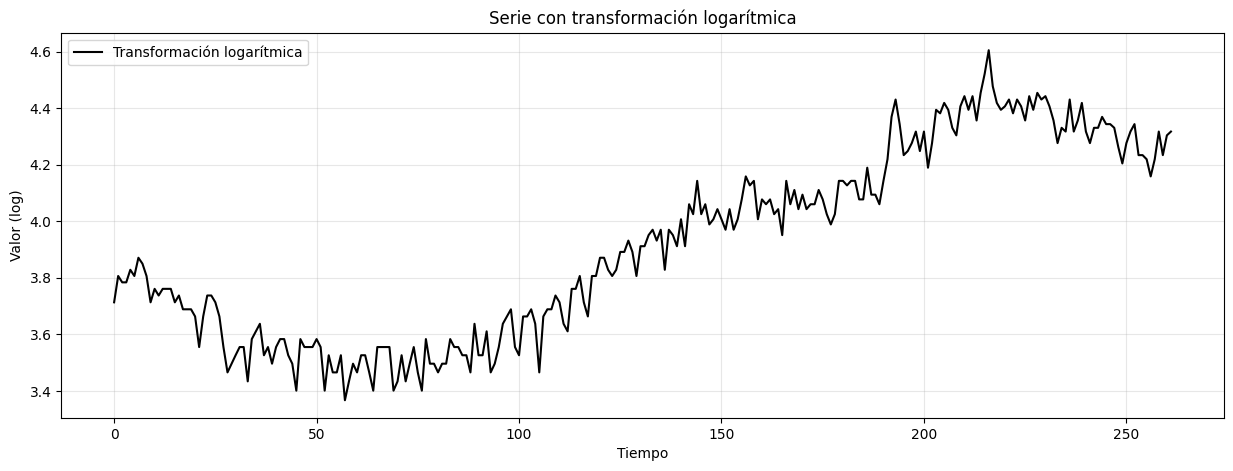

In [18]:
# Graficar serie_log
plt.figure(figsize=(15,5))
plt.plot(serie_log, color="black", label="Transformación logarítmica")
plt.xlabel("Tiempo")
plt.ylabel("Valor (log)")
plt.legend()
plt.grid(alpha=0.3)
plt.title('Serie con transformación logarítmica')
plt.show()


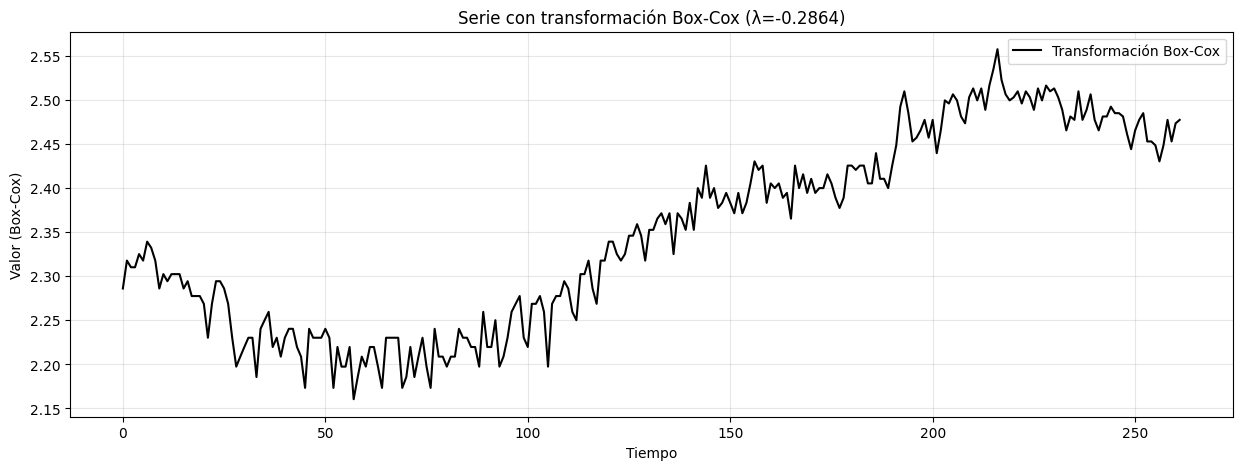

In [19]:
# Graficar serie_bc
plt.figure(figsize=(15,5))
plt.plot(serie_bc, color="black", label="Transformación Box-Cox")
plt.xlabel("Tiempo")
plt.ylabel("Valor (Box-Cox)")
plt.legend()
plt.grid(alpha=0.3)
plt.title(f'Serie con transformación Box-Cox (λ={lambda_bc:.4f})')
plt.show()


In [5]:
# --- Preparación de datos transformados (Box-Cox) para la sección de optimización ---
# Convertir serie_bc a formato similar para dividir en train/test
data_bc_for_split = pd.DataFrame(serie_bc.flatten(), columns=['value'])

# Dividir en train y test usando el mismo ratio que al inicio
time_test_ratio = 0.10
split_idx = int(len(data_bc_for_split) * (1 - time_test_ratio))
train_bc = data_bc_for_split.iloc[:split_idx]
test_bc = data_bc_for_split.iloc[split_idx:]

# Escalado de variables (MinMaxScaler)
scaler = MinMaxScaler()
scaler.fit(train_bc)
train_scaled = scaler.transform(train_bc).flatten().reshape(-1, 1)
test_scaled = scaler.transform(test_bc).flatten().reshape(-1, 1)

print(f"Train shape: {train_scaled.shape}, Test shape: {test_scaled.shape}")
print(f"Train index: {train_bc.index[0]} to {train_bc.index[-1]}")
print(f"Test index: {test_bc.index[0]} to {test_bc.index[-1]}")


Train shape: (235, 1), Test shape: (27, 1)
Train index: 0 to 234
Test index: 235 to 261


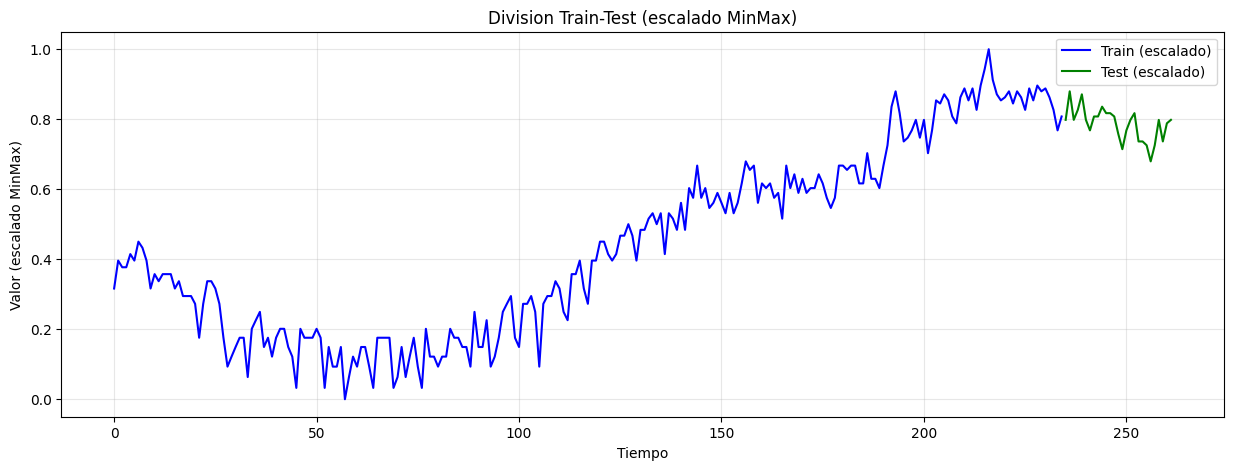

In [21]:
# Graficar train y test (escalados)
plt.figure(figsize=(15,5))
plt.plot(train_bc.index, train_scaled, color="blue", label="Train (escalado)", linewidth=1.5)
plt.plot(test_bc.index, test_scaled, color="green", label="Test (escalado)", linewidth=1.5)
plt.xlabel("Tiempo")
plt.ylabel("Valor (escalado MinMax)")
plt.legend()
plt.grid(alpha=0.3)
plt.title('Division Train-Test (escalado MinMax)')
plt.show()



Modelo 1/15 — CNN + Dense
  Lags: 7, Epochs: 300
  RMSE Train: 0.055887 | Test: 0.038365
  R² Train: 0.956260 | Test: 0.194222


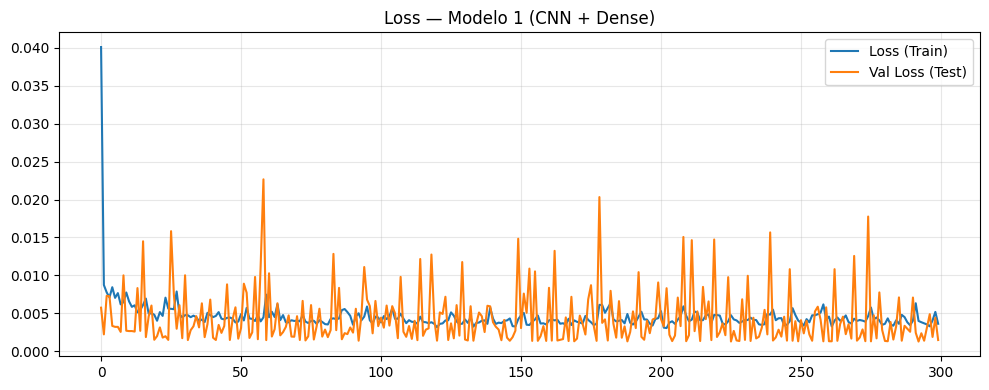

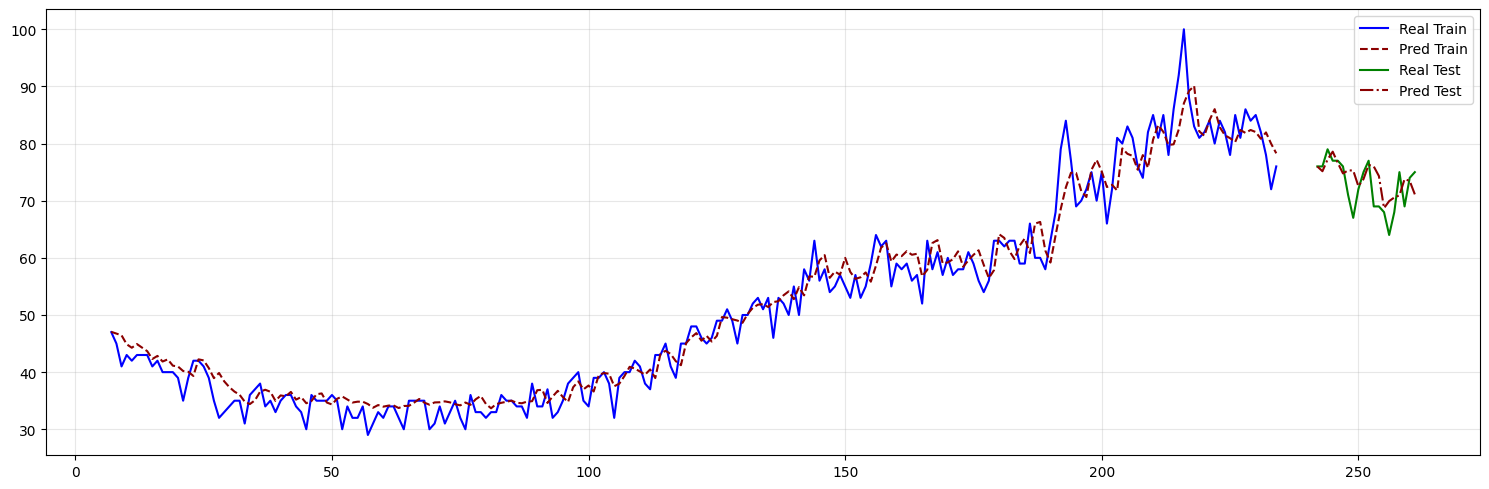

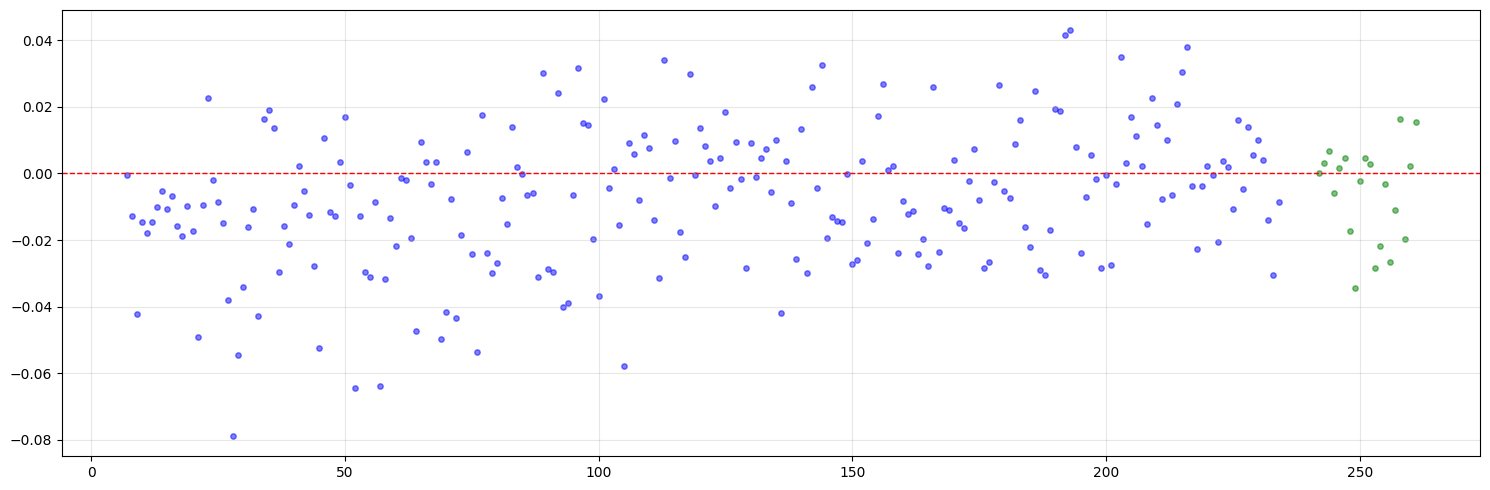

  Modelo guardado: modelo_1_CNN_Dense_lags_7.keras

Modelo 2/15 — CNN + LSTM
  Lags: 3, Epochs: 300
  RMSE Train: 0.065006 | Test: 0.066118
  R² Train: 0.939808 | Test: -1.173700


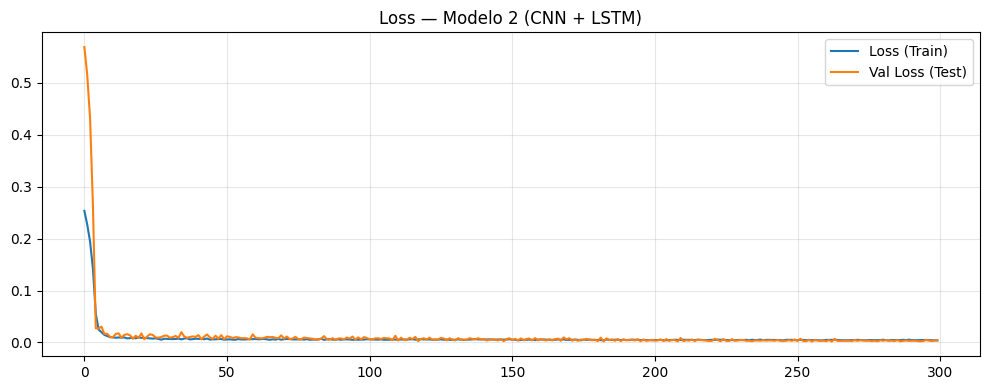

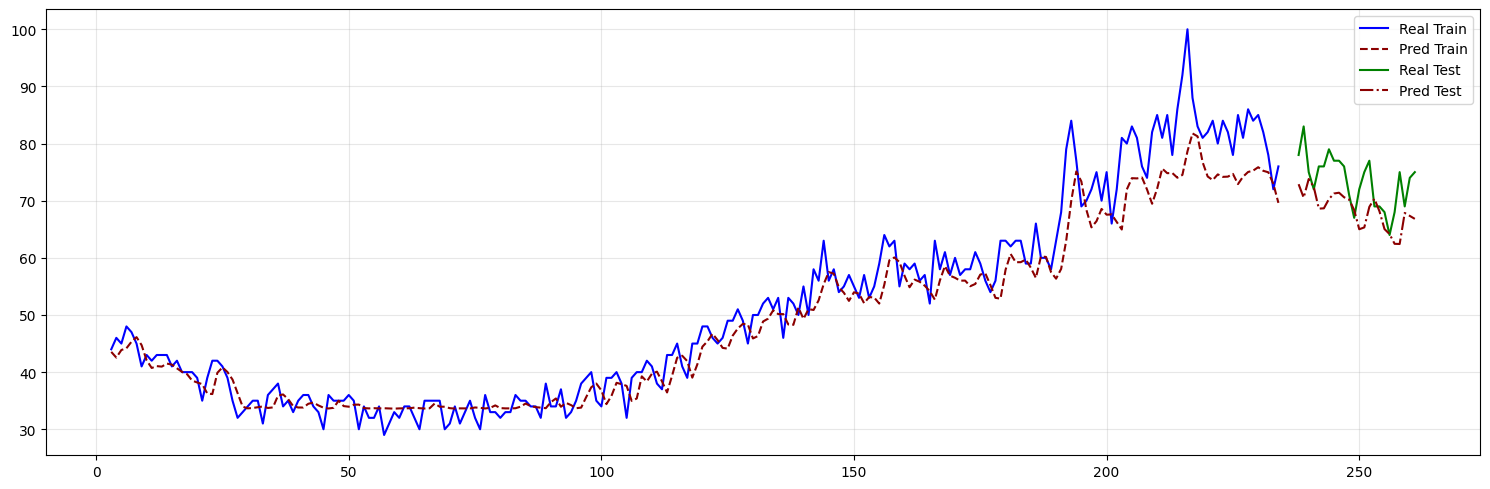

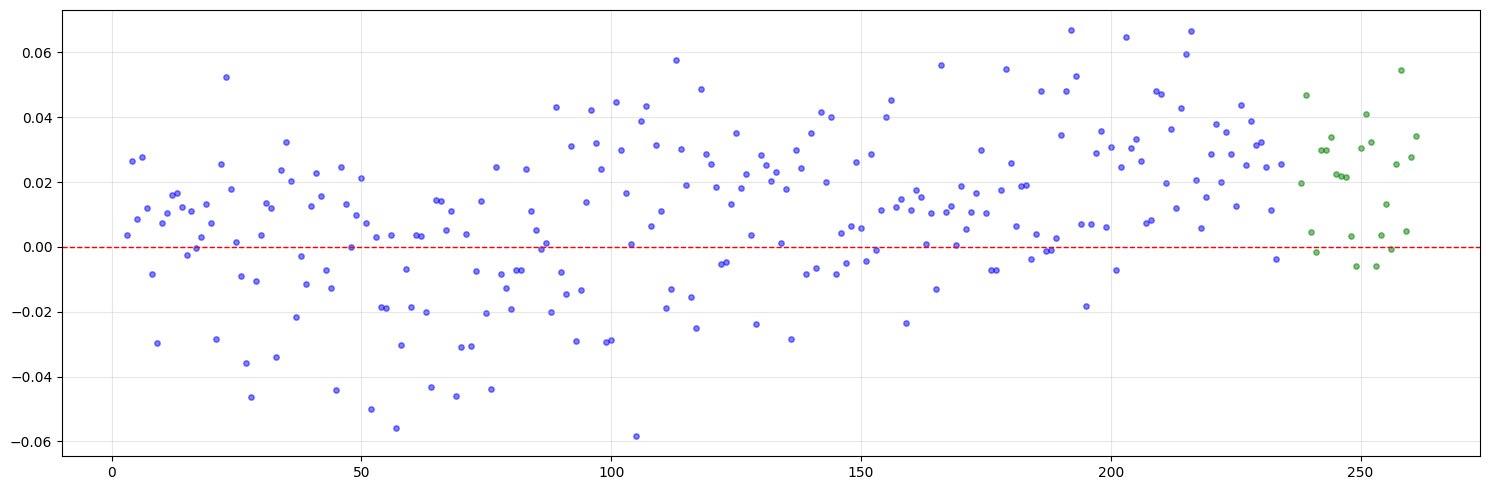

  Modelo guardado: modelo_2_CNN_LSTM_lags_3.keras

Modelo 3/15 — CNN + Dense
  Lags: 4, Epochs: 300
  RMSE Train: 0.054157 | Test: 0.042642
  R² Train: 0.958392 | Test: 0.092186


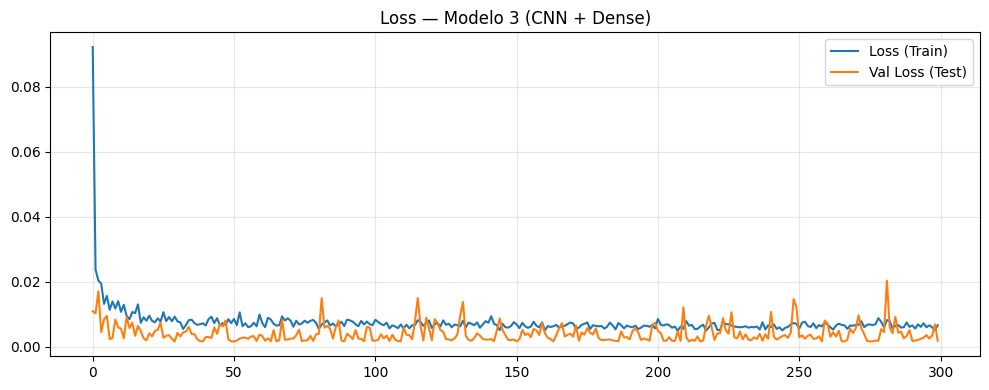

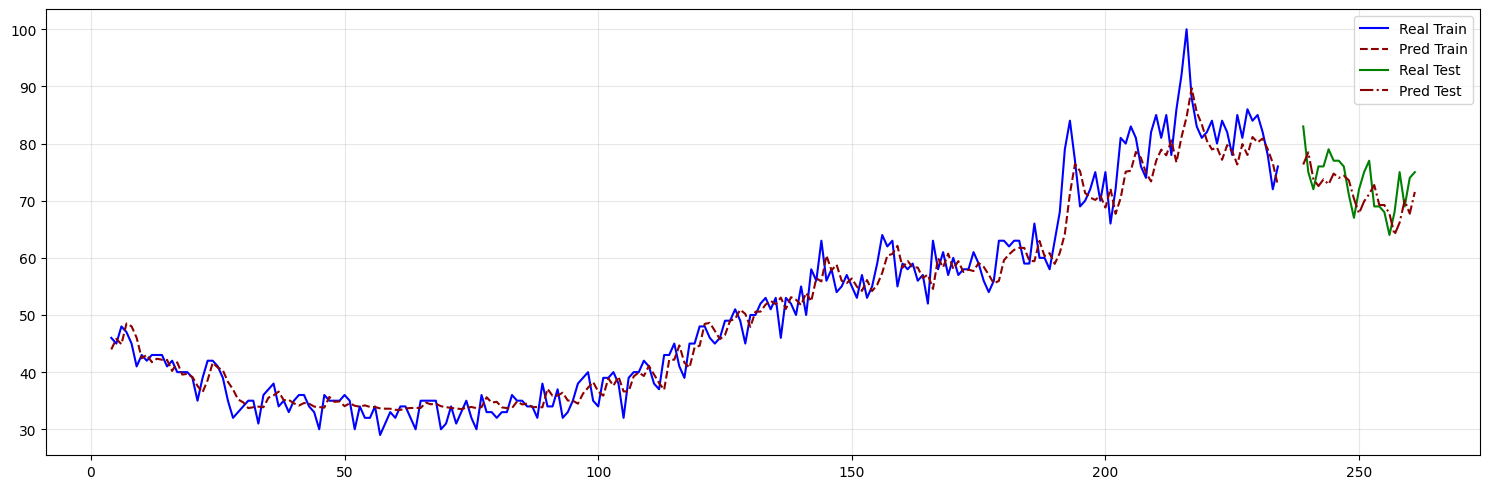

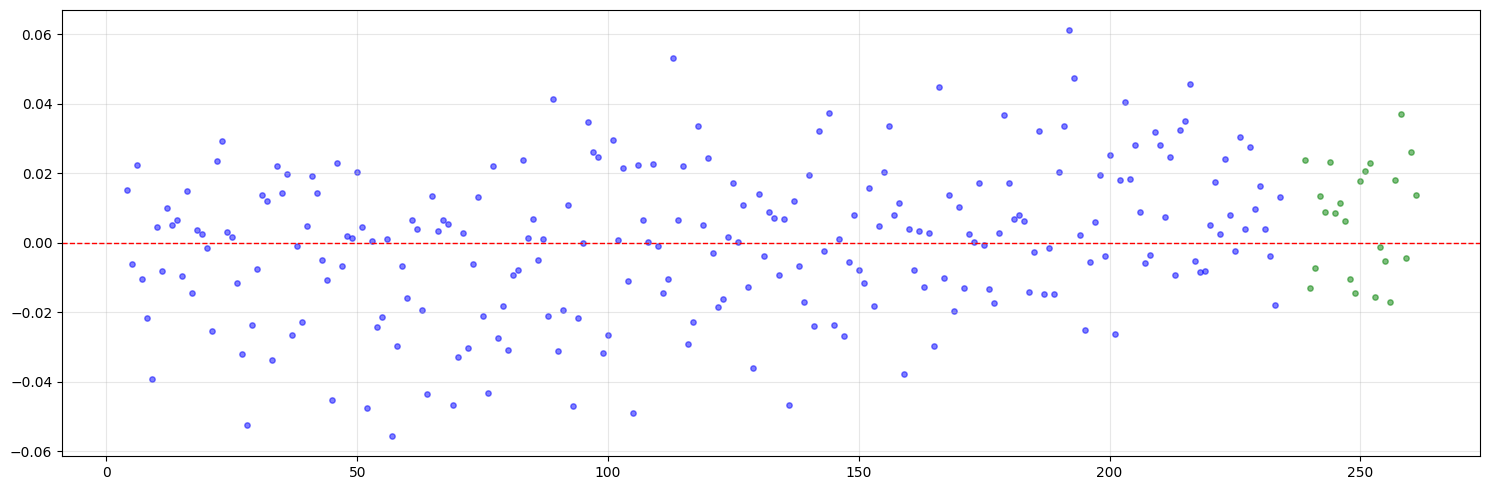

  Modelo guardado: modelo_3_CNN_Dense_lags_4.keras

Modelo 4/15 — CNN + LSTM
  Lags: 8, Epochs: 300
  RMSE Train: 0.054314 | Test: 0.039255
  R² Train: 0.958869 | Test: 0.170808


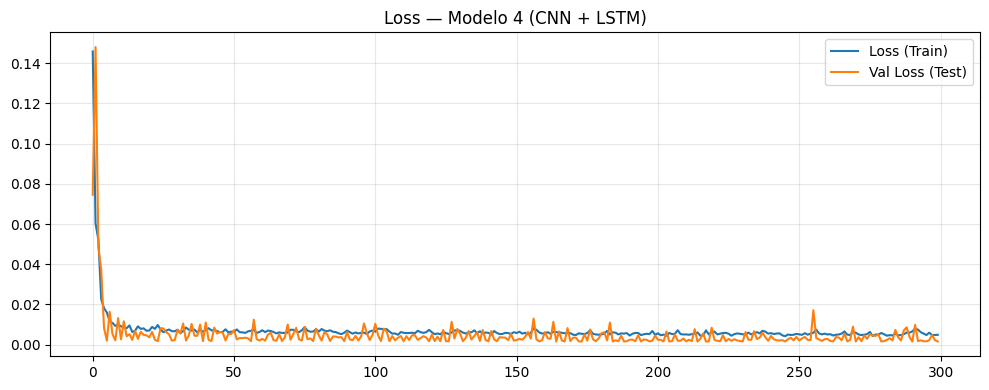

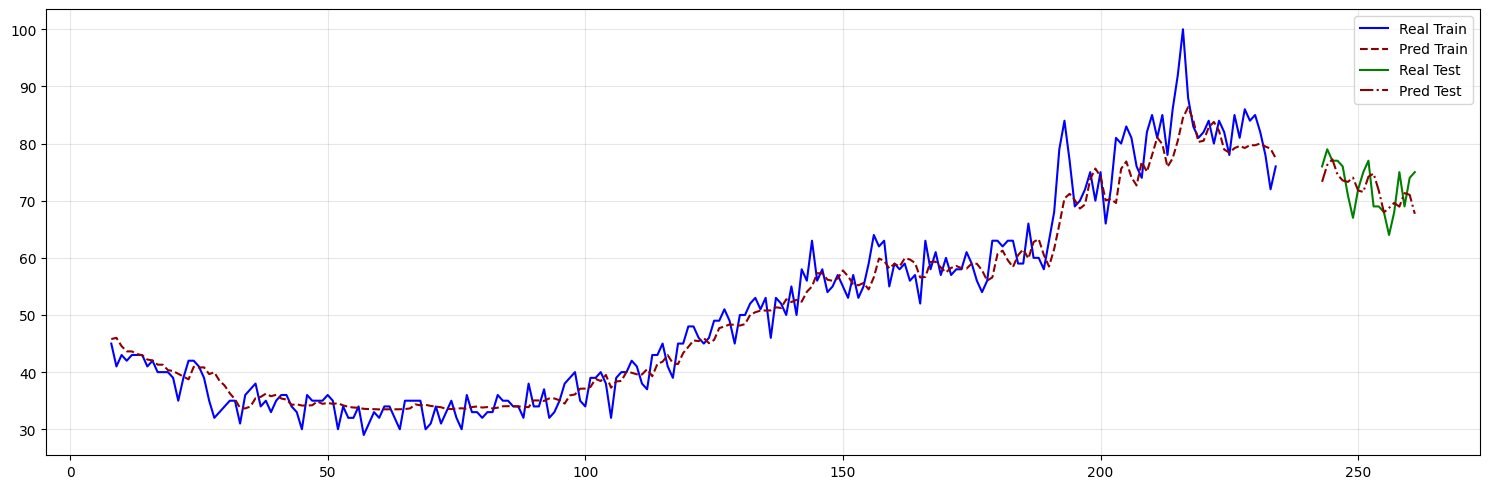

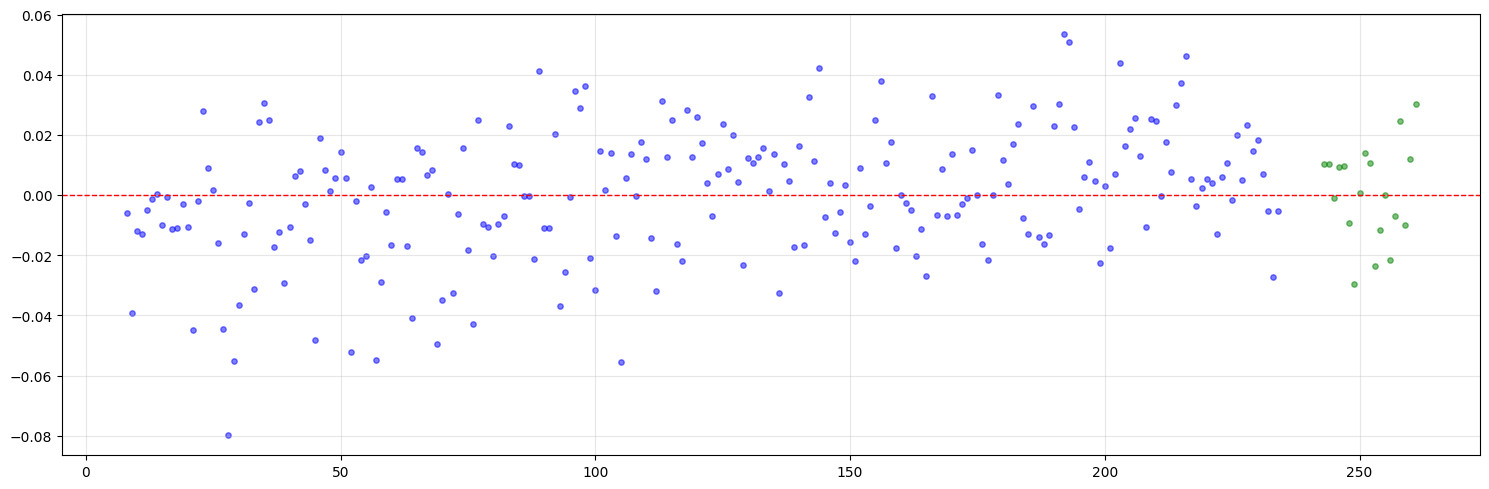

  Modelo guardado: modelo_4_CNN_LSTM_lags_8.keras

Modelo 5/15 — CNN + GRU
  Lags: 3, Epochs: 300
  RMSE Train: 0.057565 | Test: 0.064246
  R² Train: 0.952799 | Test: -1.052379


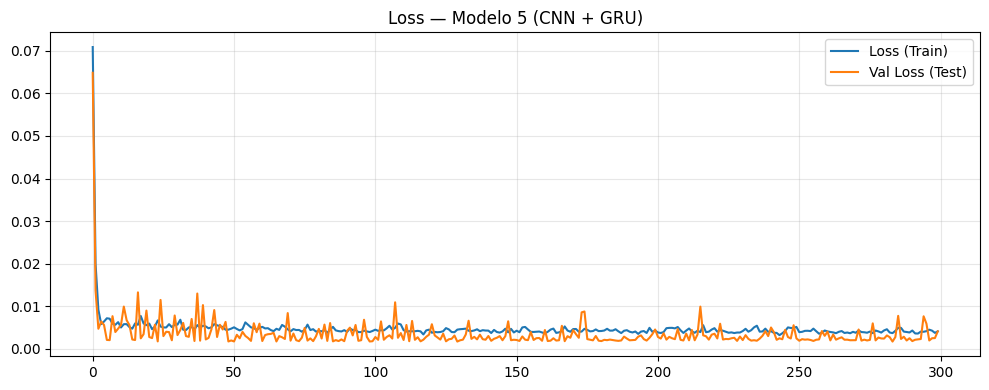

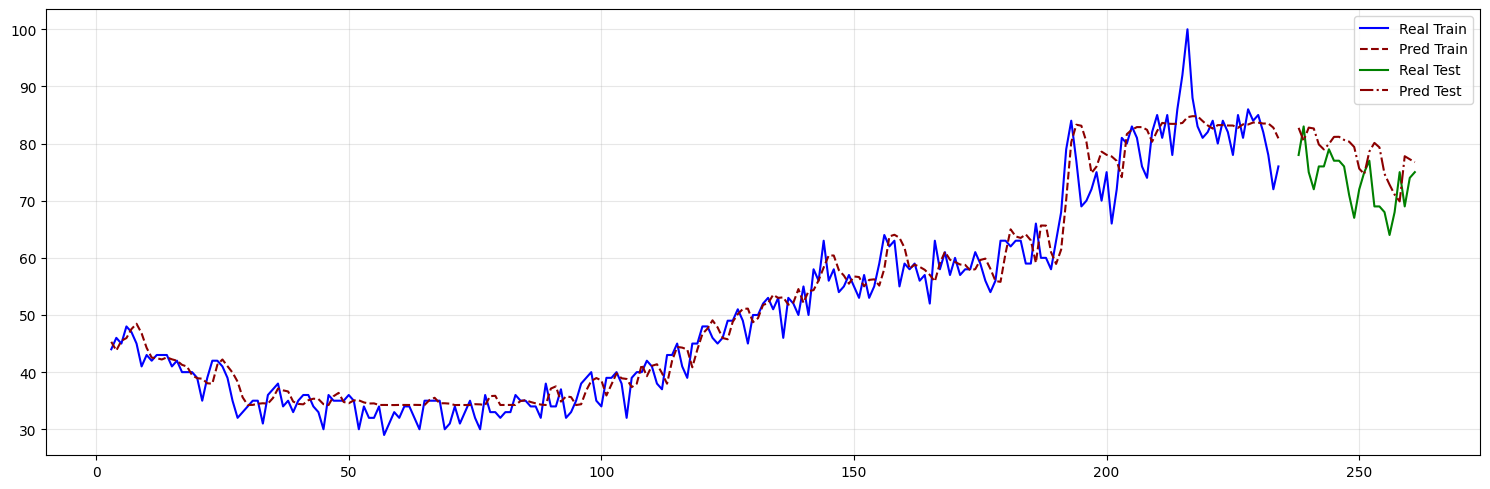

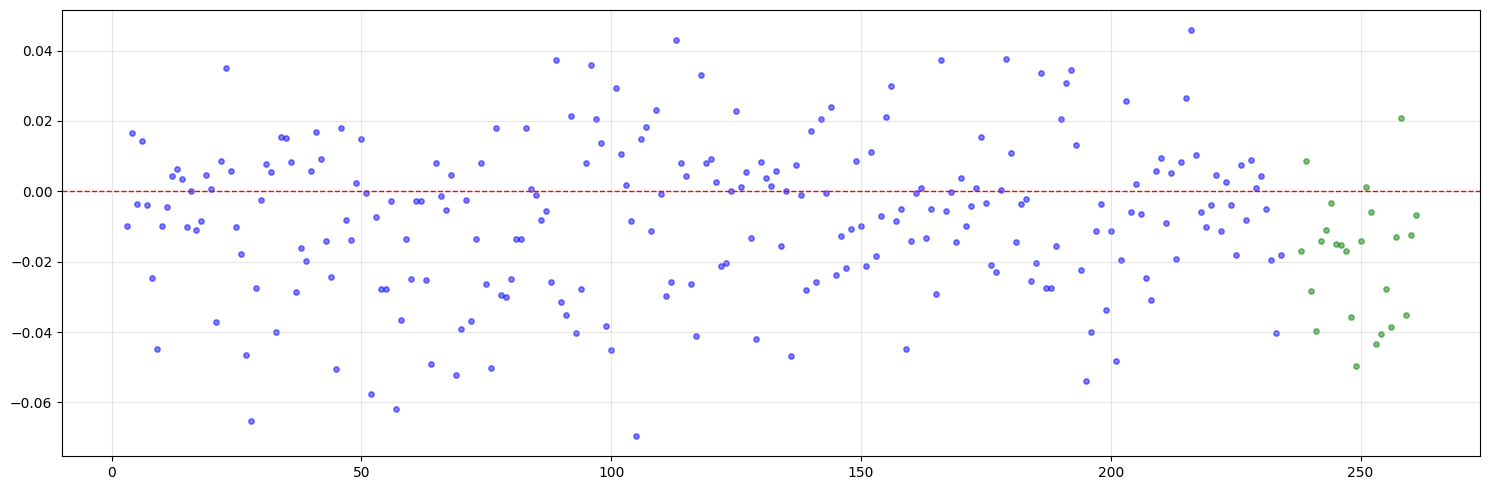

  Modelo guardado: modelo_5_CNN_GRU_lags_3.keras

Modelo 6/15 — CNN + LSTM
  Lags: 5, Epochs: 300
  RMSE Train: 0.054974 | Test: 0.043703
  R² Train: 0.957312 | Test: -0.131188


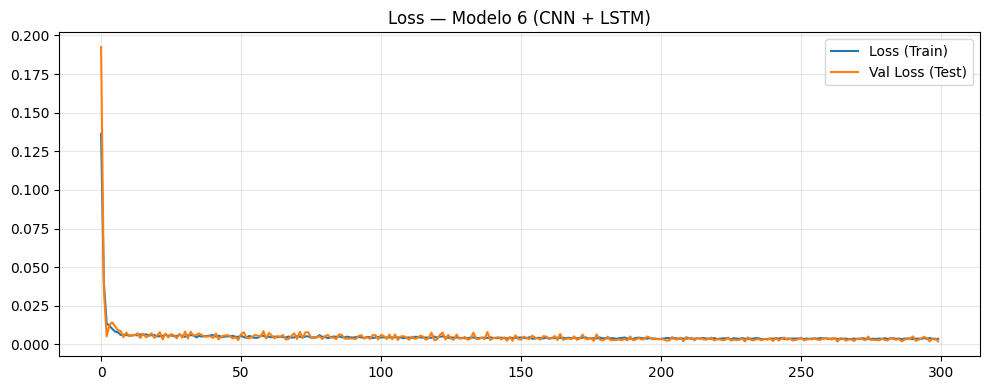

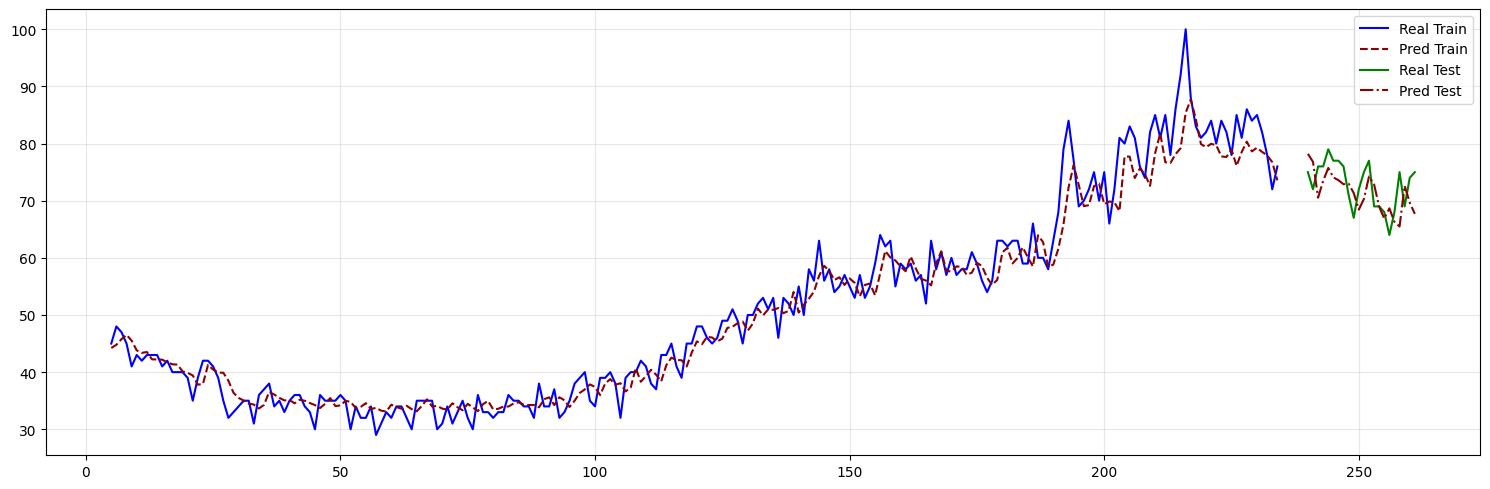

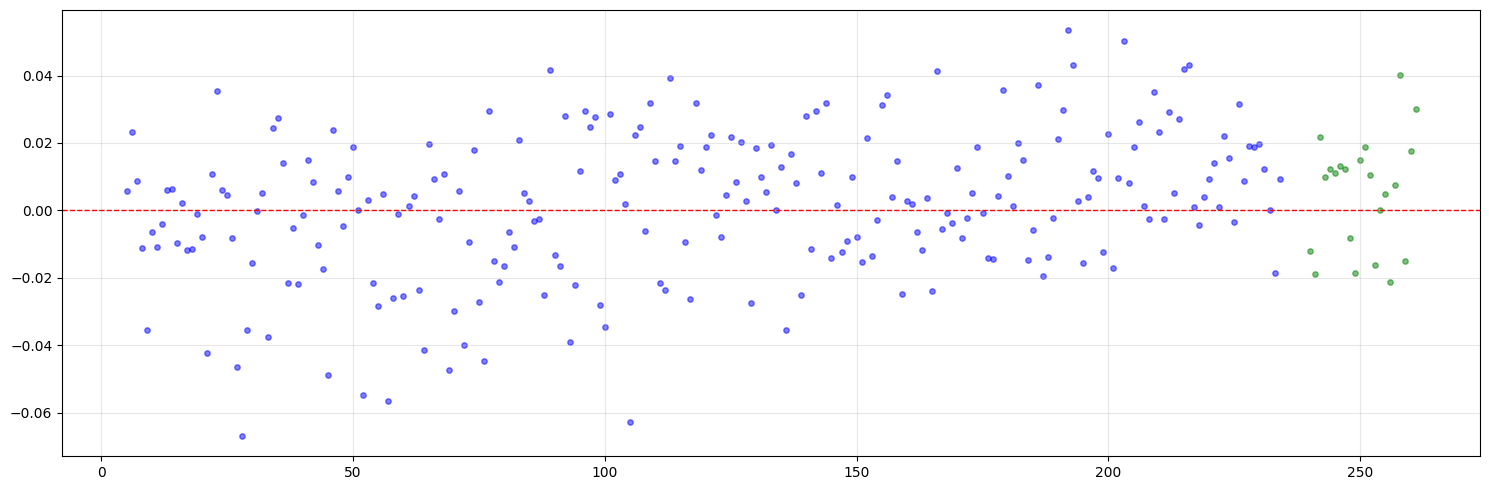

  Modelo guardado: modelo_6_CNN_LSTM_lags_5.keras

Modelo 7/15 — CNN + GRU
  Lags: 5, Epochs: 300
  RMSE Train: 0.078517 | Test: 0.077033
  R² Train: 0.912920 | Test: -2.514501


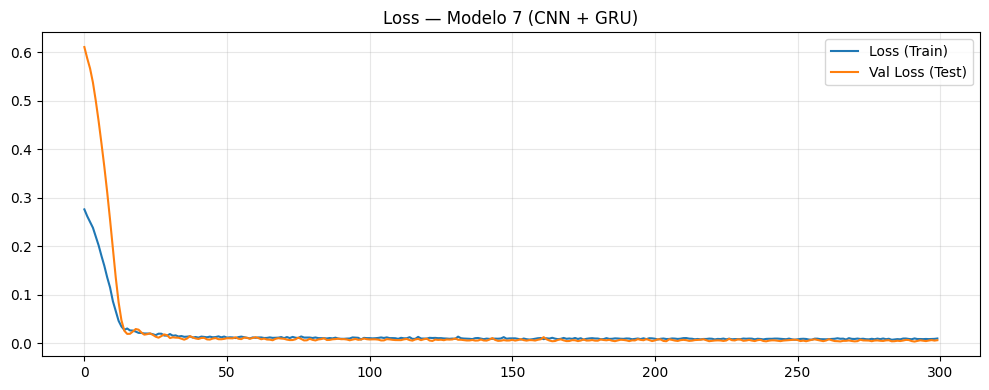

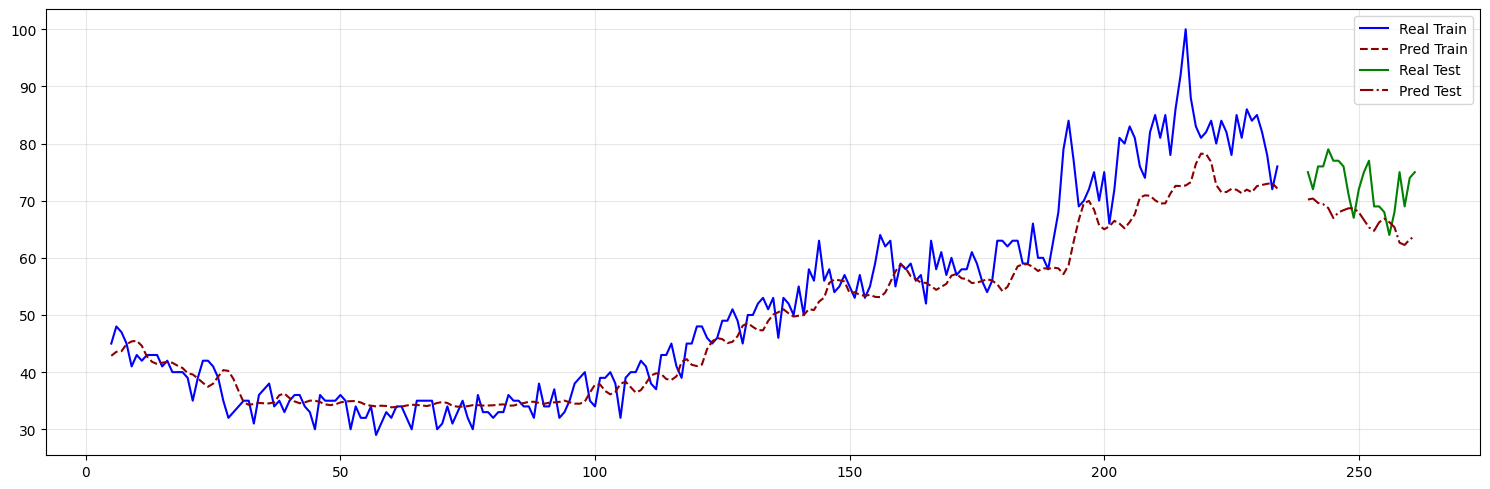

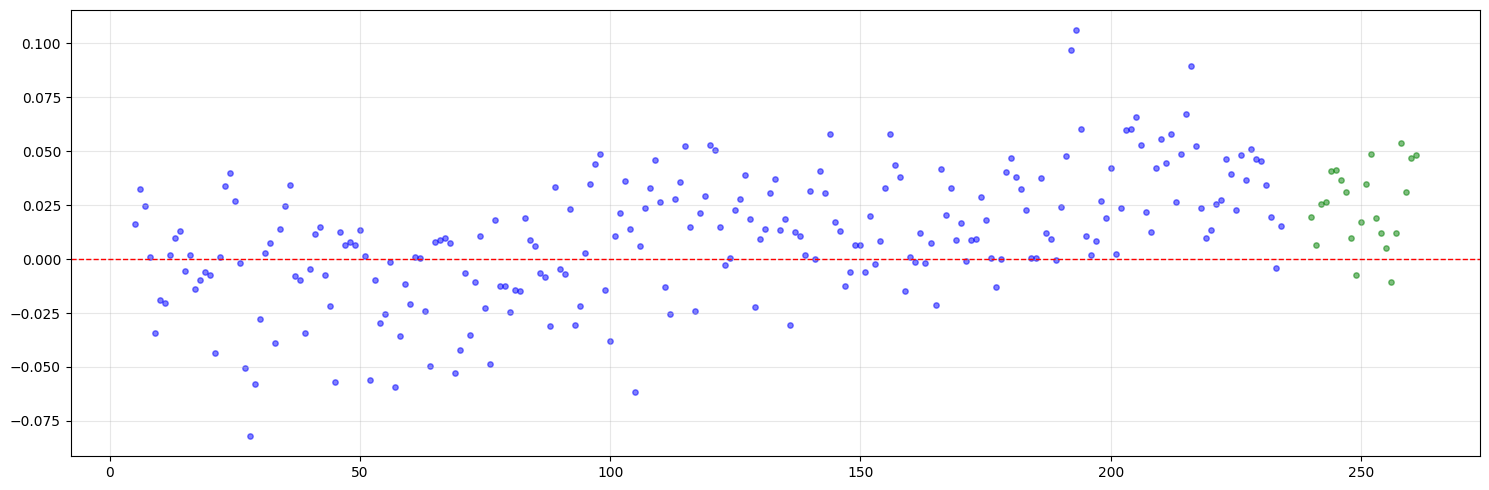

  Modelo guardado: modelo_7_CNN_GRU_lags_5.keras

Modelo 8/15 — CNN + Dense
  Lags: 9, Epochs: 300
  RMSE Train: 0.060744 | Test: 0.065346
  R² Train: 0.948775 | Test: -1.263923


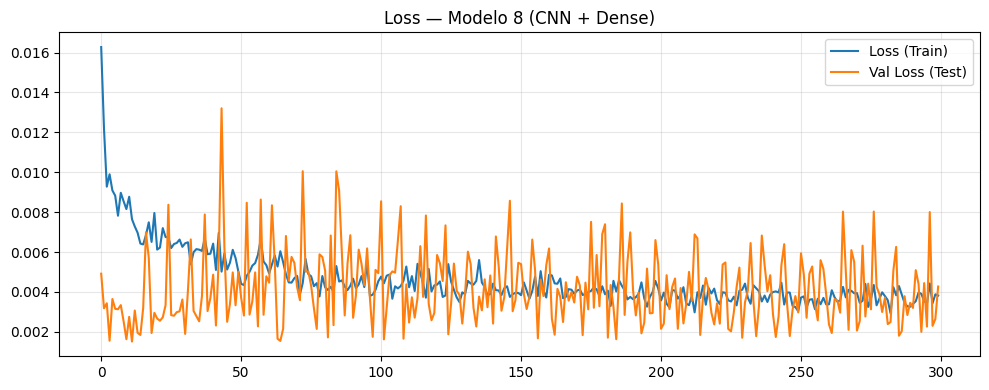

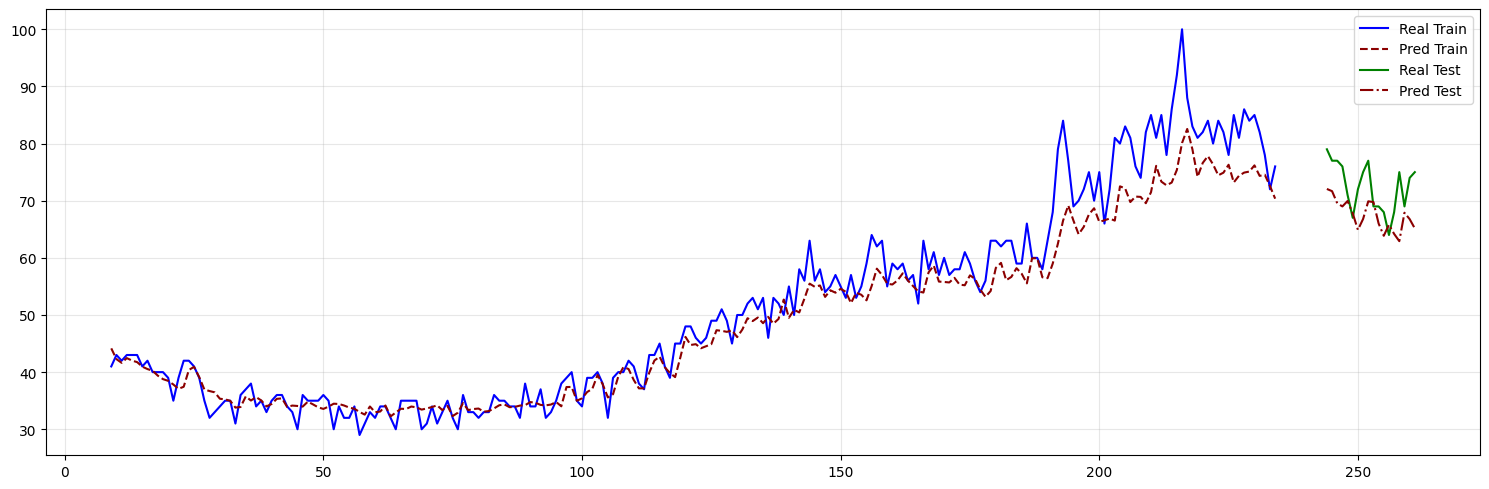

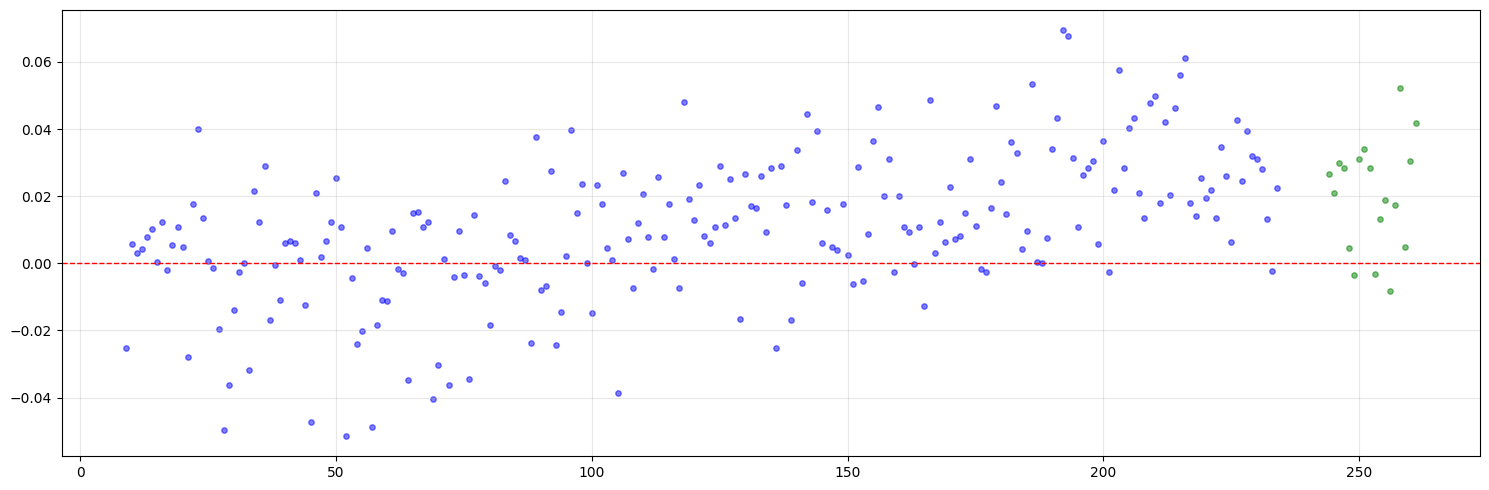

  Modelo guardado: modelo_8_CNN_Dense_lags_9.keras

Modelo 9/15 — CNN + GRU
  Lags: 4, Epochs: 300
  RMSE Train: 0.069009 | Test: 0.076771
  R² Train: 0.932444 | Test: -1.942404


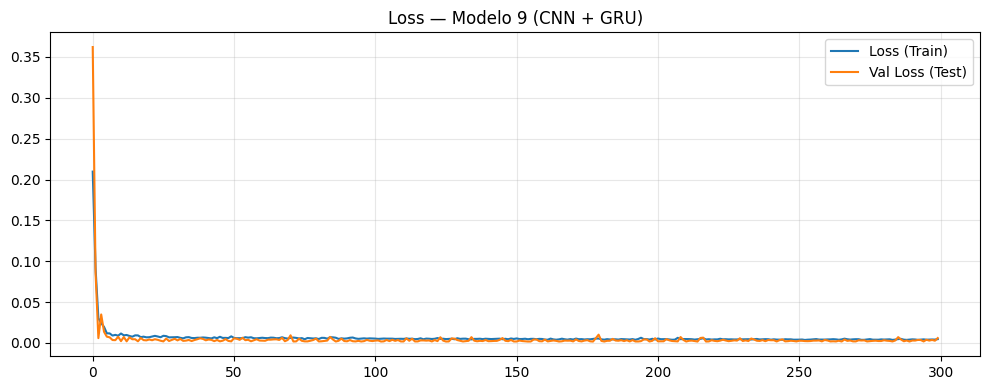

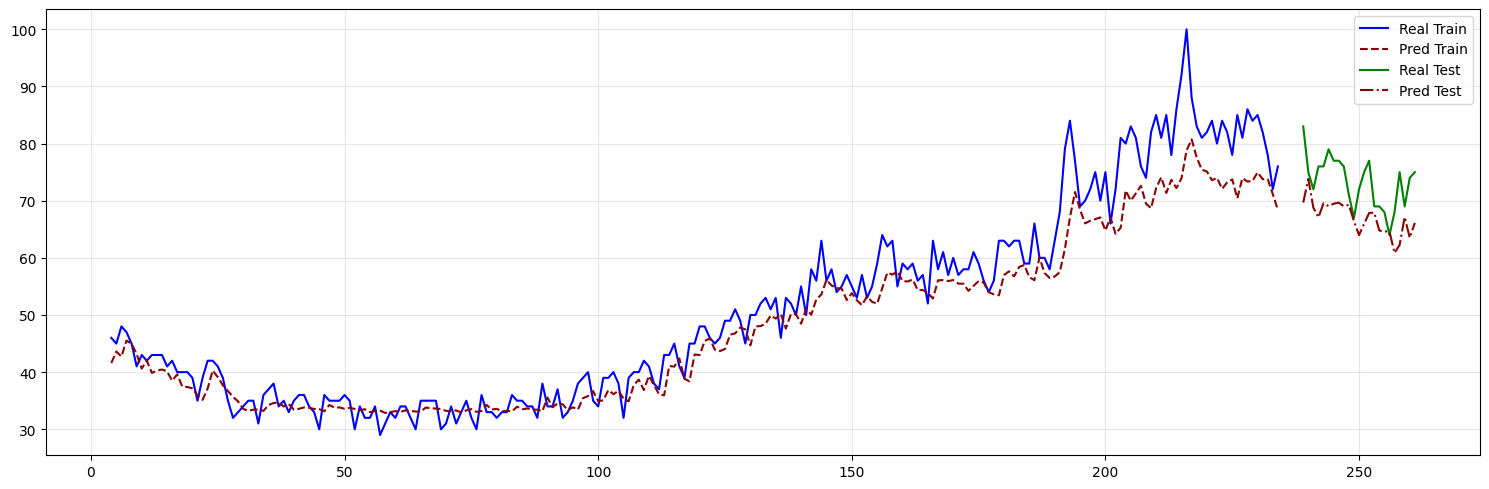

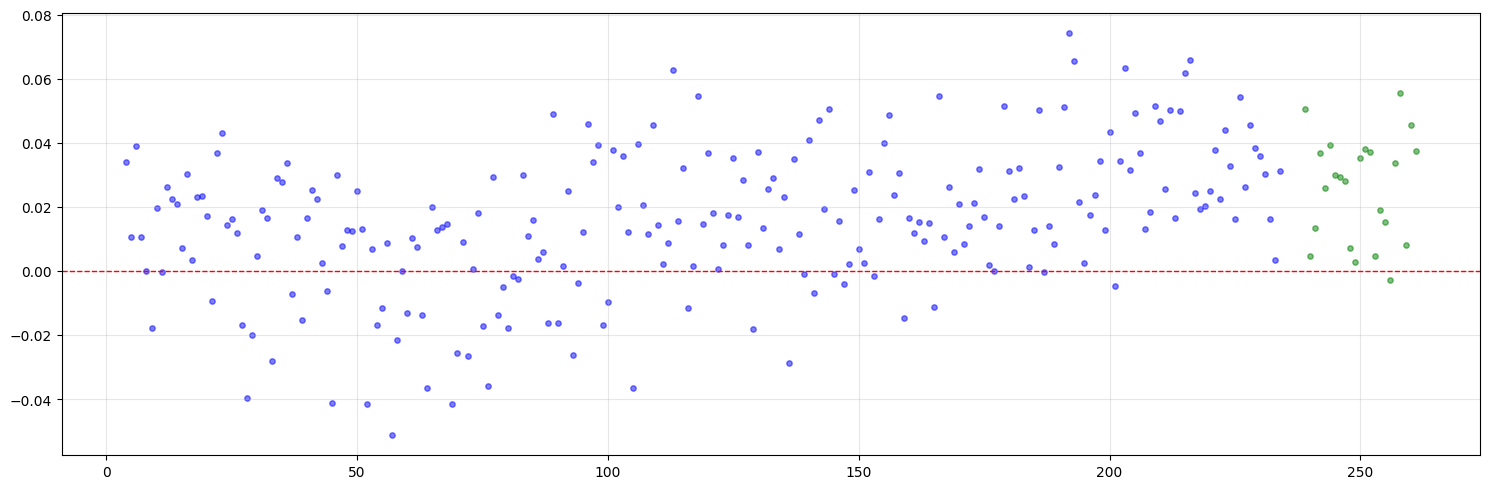

  Modelo guardado: modelo_9_CNN_GRU_lags_4.keras

Modelo 10/15 — CNN + Dense
  Lags: 5, Epochs: 300
  RMSE Train: 0.071125 | Test: 0.076339
  R² Train: 0.928544 | Test: -2.451485


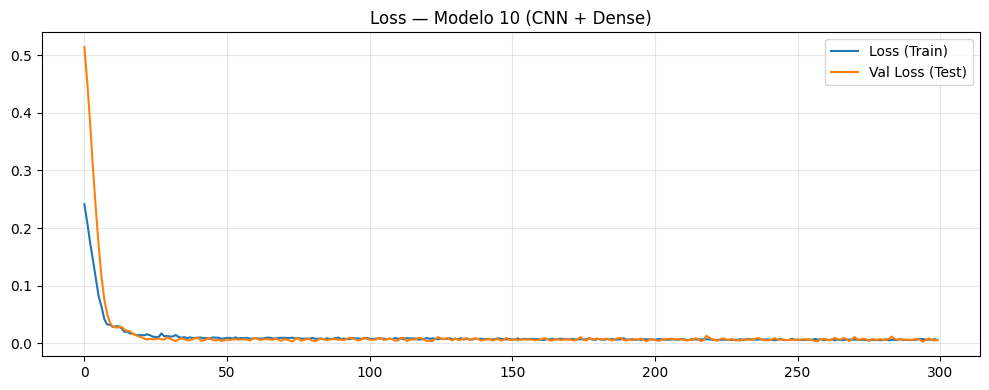

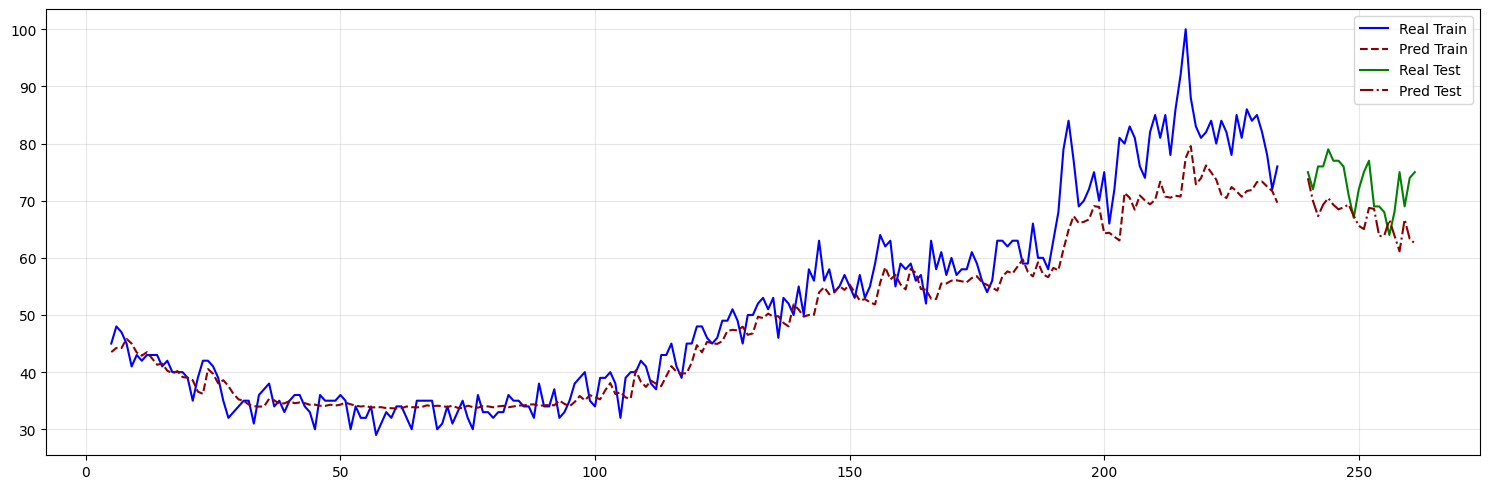

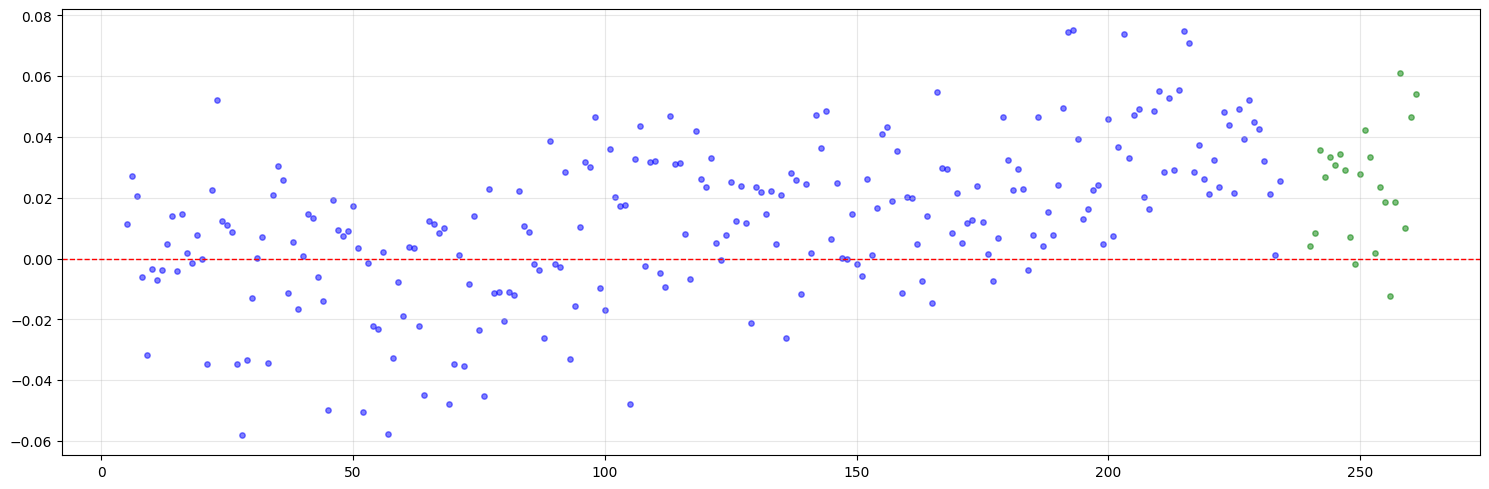

  Modelo guardado: modelo_10_CNN_Dense_lags_5.keras

Modelo 11/15 — CNN + Dense
  Lags: 3, Epochs: 300

  ✗ Error al entrenar modelo 11: Exception encountered when calling MaxPooling1D.call().

Negative dimension size caused by subtracting 2 from 1 for '{{node sequential_10_1/max_pooling1d_10_1/MaxPool1d}} = MaxPool[T=DT_FLOAT, data_format="NHWC", explicit_paddings=[], ksize=[1, 1, 2, 1], padding="VALID", strides=[1, 1, 2, 1]](sequential_10_1/max_pooling1d_10_1/MaxPool1d/ExpandDims)' with input shapes: [?,1,1,32].

Arguments received by MaxPooling1D.call():
  • inputs=tf.Tensor(shape=(None, 1, 32), dtype=float32)
  Saltando este modelo...

Modelo 12/15 — CNN + Dense
  Lags: 3, Epochs: 300
  RMSE Train: 0.062495 | Test: 0.063816
  R² Train: 0.944367 | Test: -1.024965


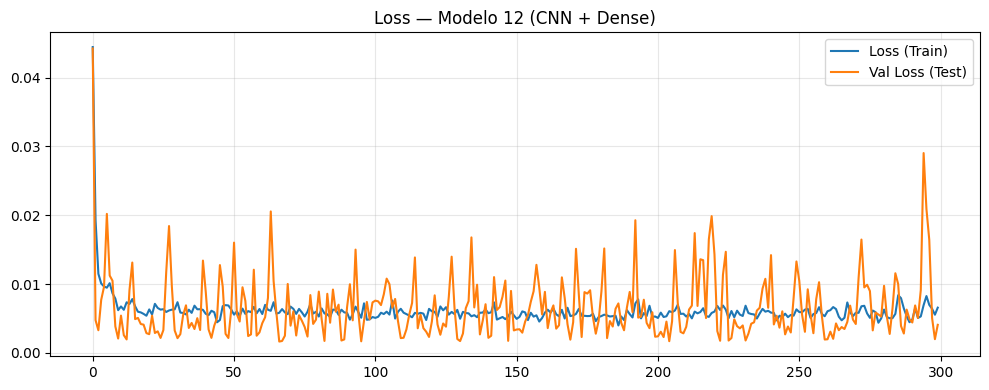

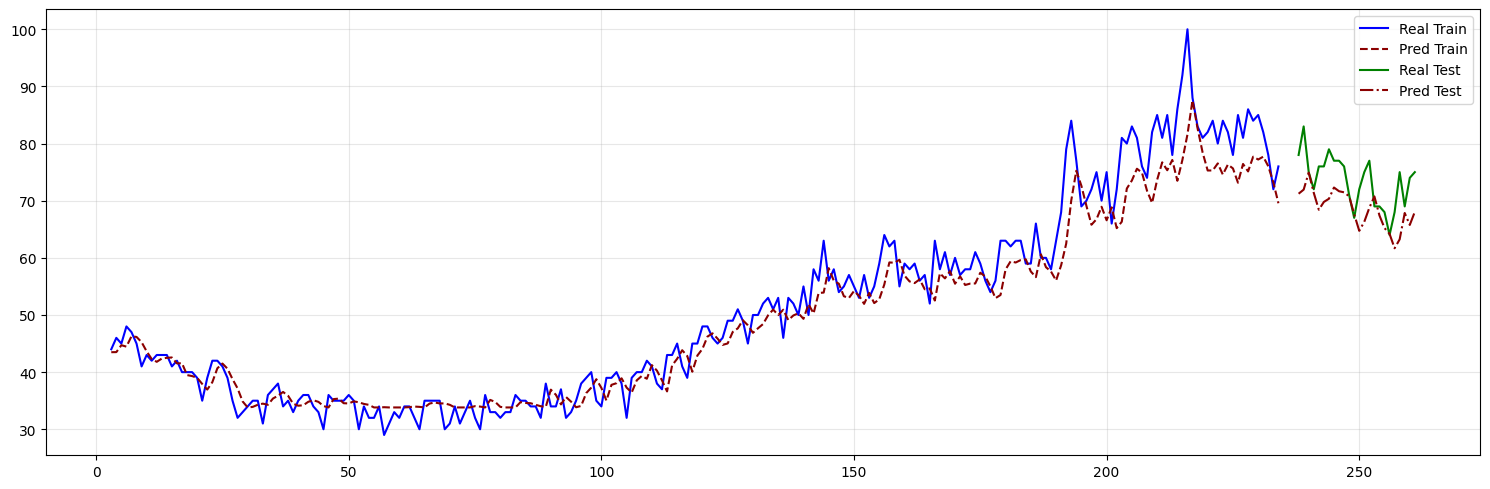

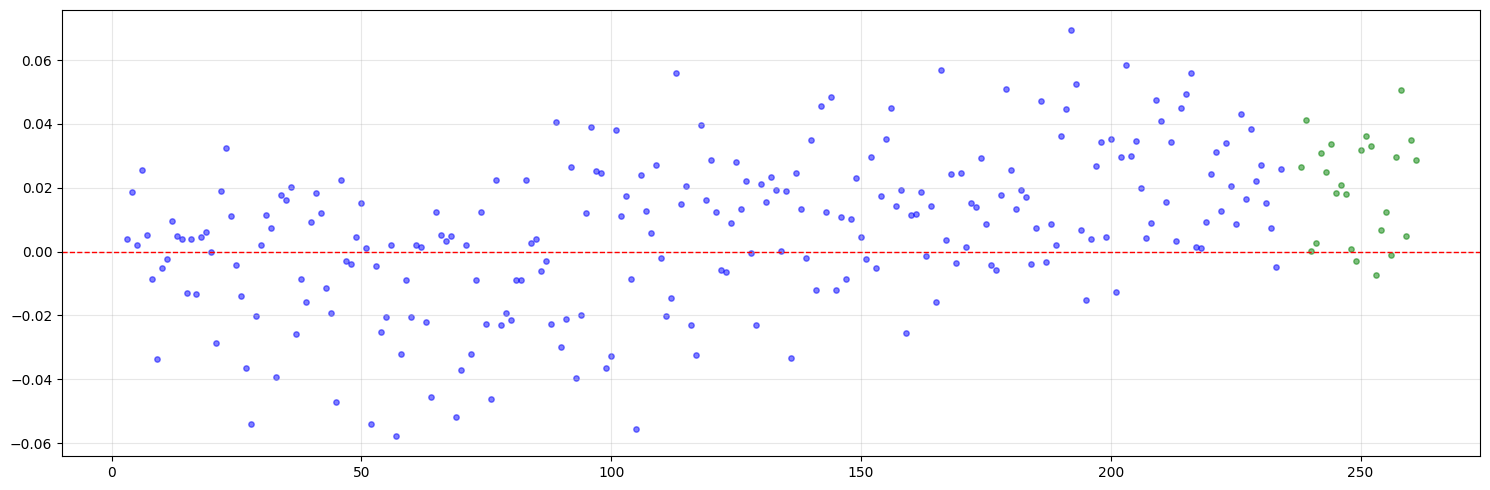

  Modelo guardado: modelo_12_CNN_Dense_lags_3.keras

Modelo 13/15 — CNN + LSTM
  Lags: 3, Epochs: 300
  RMSE Train: 0.062559 | Test: 0.054916
  R² Train: 0.944254 | Test: -0.499529


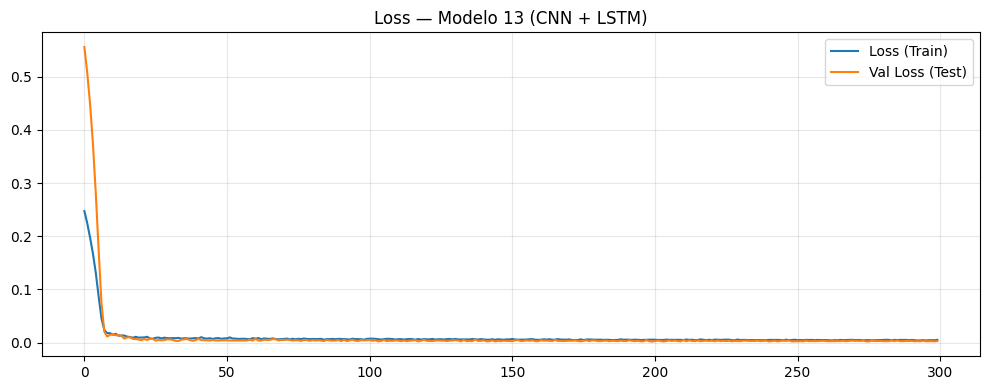

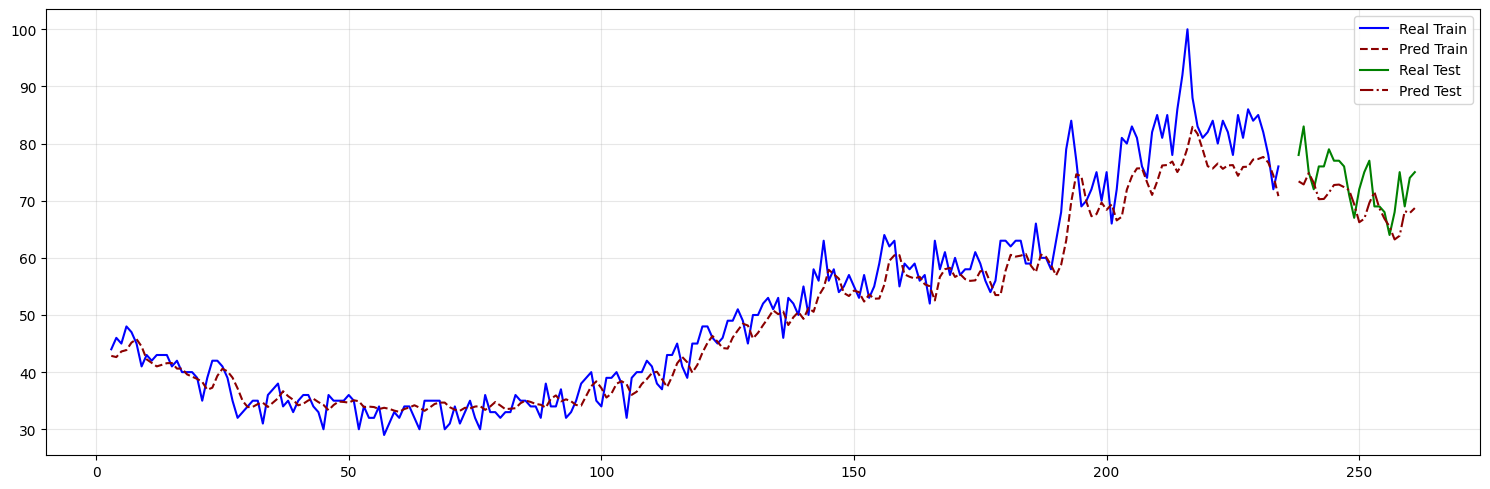

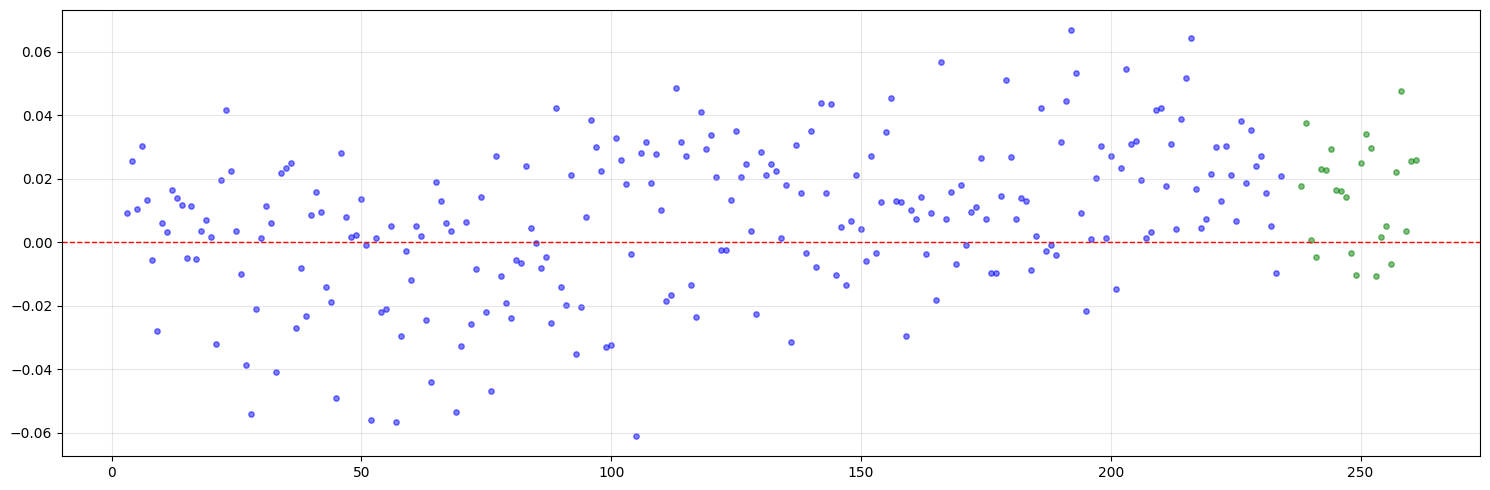

  Modelo guardado: modelo_13_CNN_LSTM_lags_3.keras

Modelo 14/15 — CNN + LSTM
  Lags: 6, Epochs: 300
  RMSE Train: 0.062282 | Test: 0.048887
  R² Train: 0.945440 | Test: -0.372664


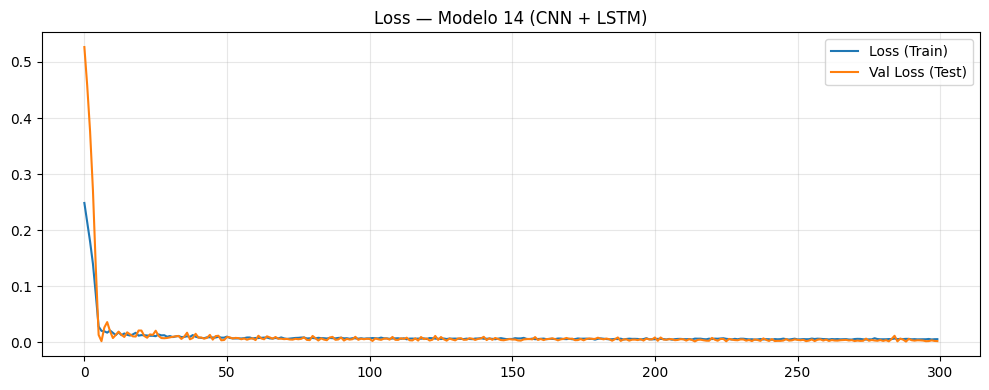

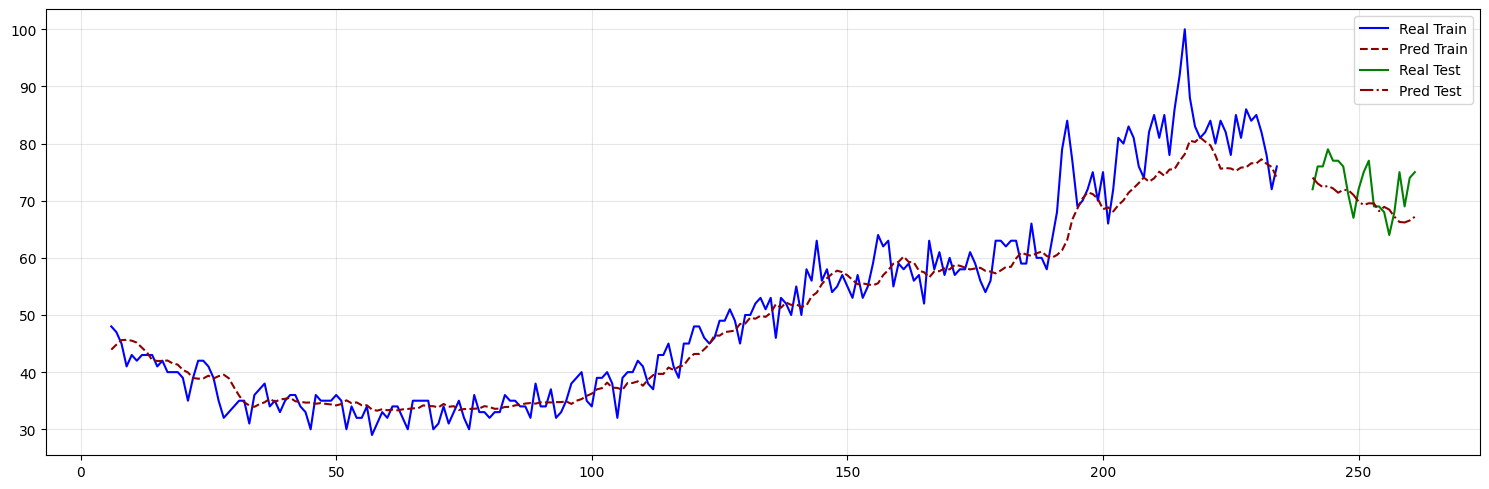

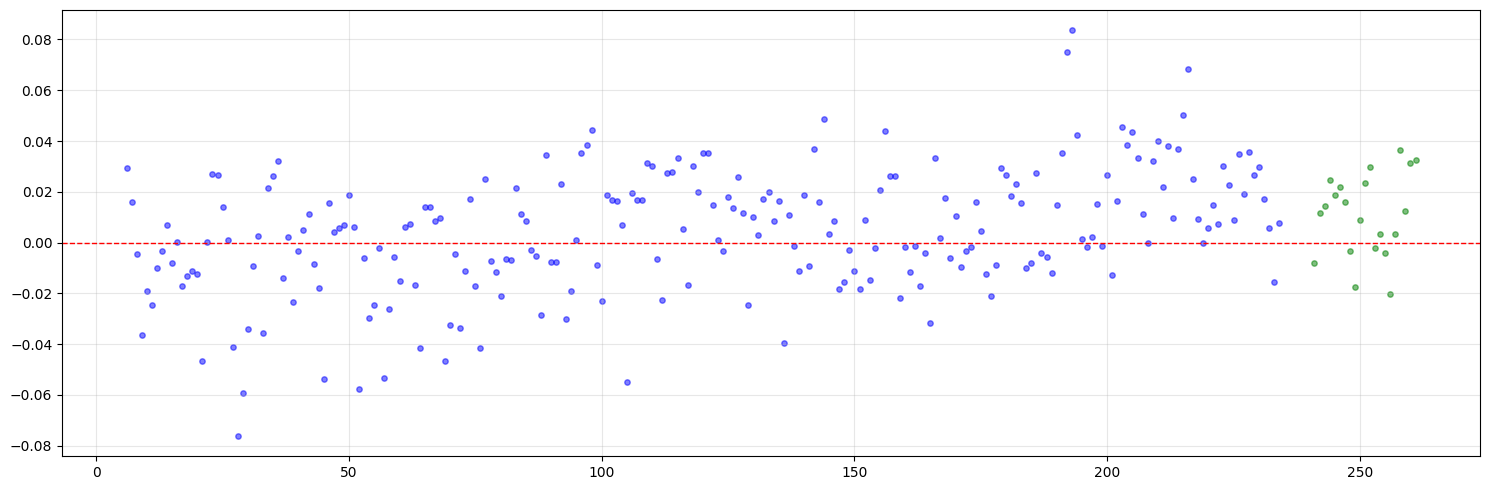

  Modelo guardado: modelo_14_CNN_LSTM_lags_6.keras

Modelo 15/15 — CNN + LSTM
  Lags: 4, Epochs: 300
  RMSE Train: 0.059689 | Test: 0.053805
  R² Train: 0.949458 | Test: -0.445278


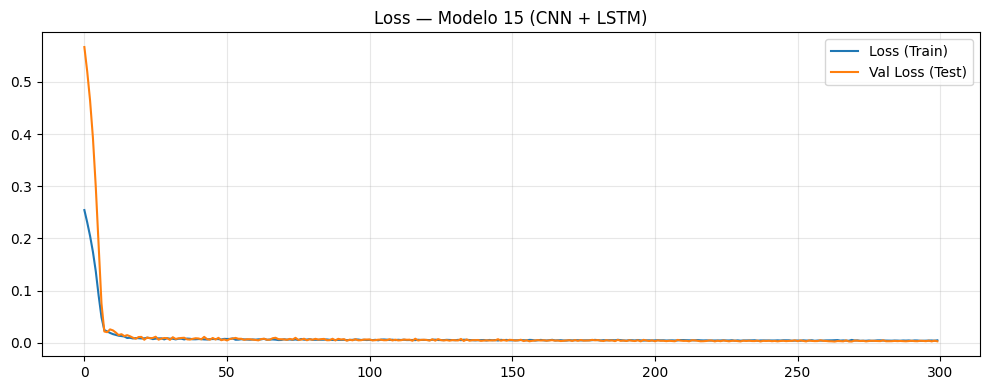

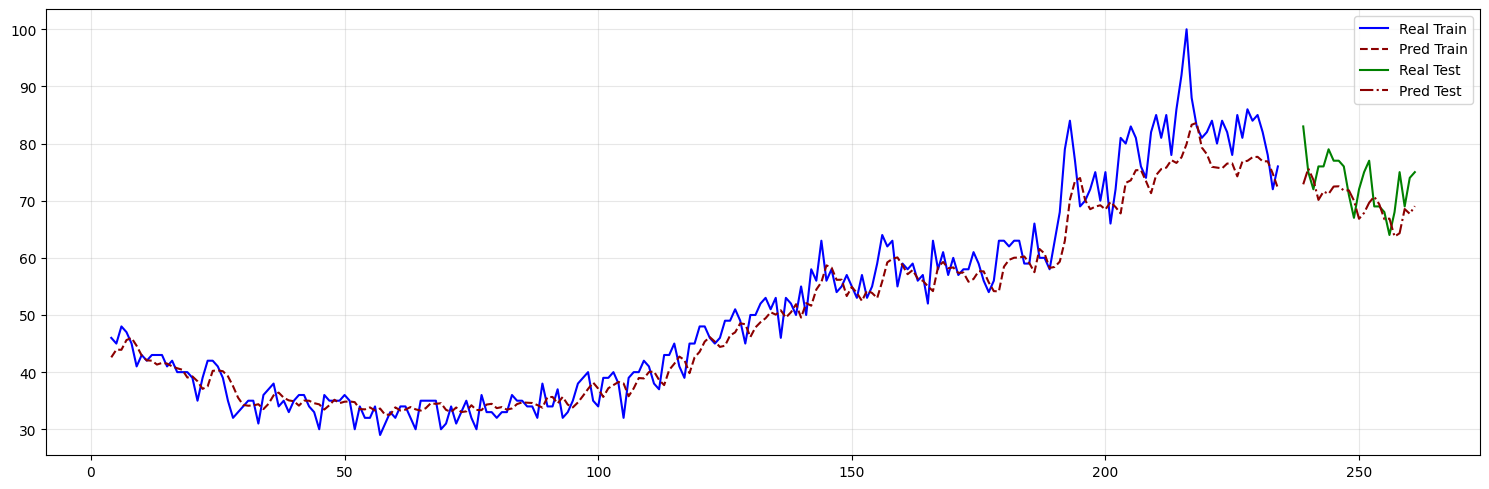

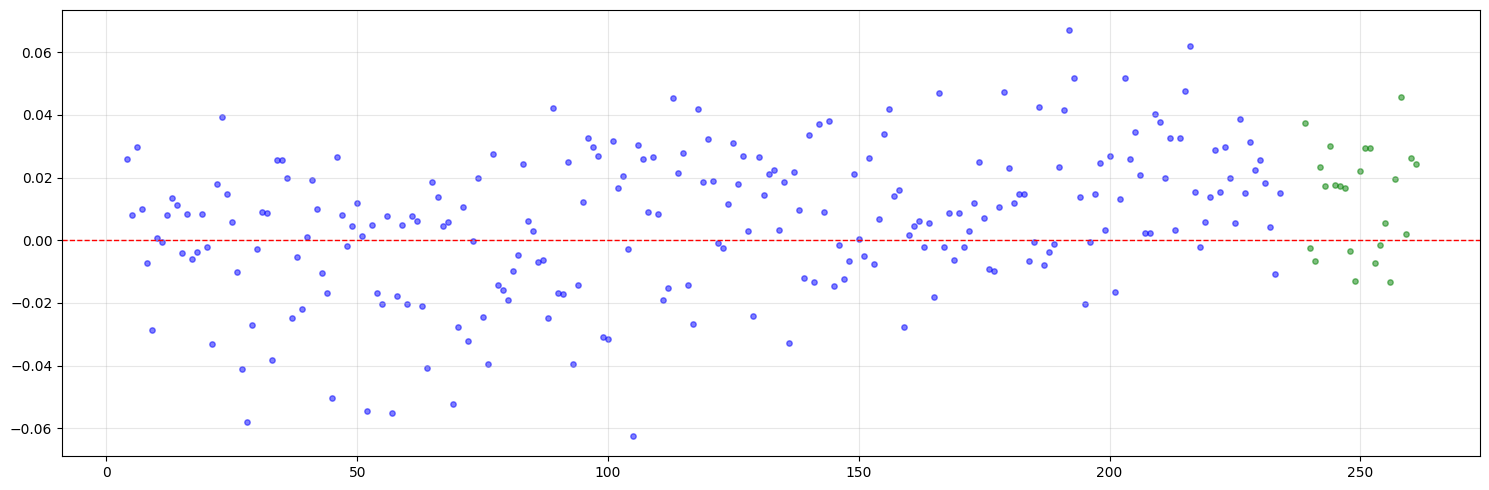

  Modelo guardado: modelo_15_CNN_LSTM_lags_4.keras

RESUMEN DE RESULTADOS
    modelo   tipo_red  lags  filters  kernel_size  pool_size  n_conv_layers  \
0        1  CNN+Dense     7       32            3          2              1   
1        2   CNN+LSTM     3       32            2          2              1   
2        3  CNN+Dense     4       16            2          2              1   
3        4   CNN+LSTM     8       16            3          2              1   
4        5    CNN+GRU     3       16            2          2              1   
5        6   CNN+LSTM     5       16            2          2              1   
6        7    CNN+GRU     5       32            3          2              1   
7        8  CNN+Dense     9       32            2          2              1   
8        9    CNN+GRU     4       32            3          2              1   
9       10  CNN+Dense     5       16            2          2              1   
10      12  CNN+Dense     3       16            3        

In [13]:
resultados_df, predicciones = entrenar_modelos_cnn_ts(
    train_scaled=train_scaled,
    test_scaled=test_scaled,
    train_index=train_bc.index,
    test_index=test_bc.index,
    prepare_data=prepare_data,
    lags=[3, 4, 5, 6, 7, 8, 9, 10],
    cantidad_modelos=15,
    filters=[16, 32],
    kernel_size=[2, 3],
    pool_size=2,
    n_conv_layers=[1],
    strides=1,
    padding=["same", "valid"],
    post_cnn_type=["LSTM", "GRU", "Dense"],
    post_cnn_units=[20, 25, 30],
    n_post_cnn_layers=[1, 2],
    activation_conv="relu",
    activation_post=["tanh", "relu"],
    learning_rate=[0.01, 0.001, 0.0005],
    batch_size=[16, 32],
    optimizer=["Adam"],
    Dropout_rate=[0.1],
    epochs=[300],
    loss="mse",
    scaler=scaler,
    transformacion="boxcox",
    lambda_bc=lambda_bc,
    guardar_modelos=True,
    graficar_loss=True,
    graficar_ajuste=True,
    graficar_residuales=True,
)

print("\n" + "="*60)
print("RESUMEN DE RESULTADOS")
print("="*60)
print(resultados_df)


# Mejores Modelos CNN
En esta sección se realizo el codigo que permite evaluar los residuales de los mejores modelos CNN.

## Modelo 1 - CNN_Dense

In [50]:
# Cargar modelo keras
from keras.models import load_model

model = load_model('modelo_1_CNN_Dense_lags_7.keras')

# Creacion de lags (debe coincidir con el modelo cargado)
lags = 7
X_train, y_train = prepare_data_rnn(train_scaled, lags)
X_test, y_test = prepare_data_rnn(test_scaled, lags)

In [51]:
# Funciones de evaluacion y analisis para el modelo cargado
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import probplot, norm

def evaluar_modelo_ts(model, X_train, y_train, X_test, y_test, train_index, test_index, lags, scaler=None, transformacion=None, lambda_bc=None, nombre_modelo="Modelo", nombre_serie="Serie"):
    def invertir(valores):
        resultado = np.asarray(valores).reshape(-1, 1)
        if scaler is not None:
            resultado = scaler.inverse_transform(resultado)
        resultado = resultado.flatten()
        if transformacion == "log":
            resultado = np.exp(resultado)
        elif transformacion == "boxcox":
            if lambda_bc is None:
                raise ValueError("Se requiere lambda_bc para invertir Box-Cox.")
            resultado = inv_boxcox(resultado, lambda_bc)
        return resultado

    y_train_pred = model.predict(X_train, verbose=0).flatten()
    y_test_pred = model.predict(X_test, verbose=0).flatten()

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    y_train_inv = invertir(y_train)
    y_test_inv = invertir(y_test)
    y_train_pred_inv = invertir(y_train_pred)
    y_test_pred_inv = invertir(y_test_pred)

    rmse_train_inv = np.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
    rmse_test_inv = np.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
    mae_train_inv = mean_absolute_error(y_train_inv, y_train_pred_inv)
    mae_test_inv = mean_absolute_error(y_test_inv, y_test_pred_inv)
    r2_train_inv = r2_score(y_train_inv, y_train_pred_inv)
    r2_test_inv = r2_score(y_test_inv, y_test_pred_inv)

    print("═" * 62)
    print(f"  {nombre_modelo} | {nombre_serie}")
    print("═" * 62)
    print("\n  ▸ Espacio escalado/transformado:")
    print("    Métrica             Train         Test")
    print("    ────────────────────────────────────")
    print(f"    RMSE           {rmse_train:10.6f}  {rmse_test:12.6f}")
    print(f"    MAE            {mae_train:10.6f}  {mae_test:12.6f}")
    print(f"    R²             {r2_train:10.6f}  {r2_test:12.6f}")

    print("\n  ▸ Escala original:")
    print("    Métrica             Train         Test")
    print("    ────────────────────────────────────")
    print(f"    RMSE           {rmse_train_inv:10.4f}  {rmse_test_inv:12.4f}")
    print(f"    MAE            {mae_train_inv:10.4f}  {mae_test_inv:12.4f}")
    print(f"    R²             {r2_train_inv:10.6f}  {r2_test_inv:12.6f}")
    print("═" * 62)

    return {
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "mae_train": mae_train,
        "mae_test": mae_test,
        "r2_train": r2_train,
        "r2_test": r2_test,
        "rmse_train_original": rmse_train_inv,
        "rmse_test_original": rmse_test_inv,
        "mae_train_original": mae_train_inv,
        "mae_test_original": mae_test_inv,
        "r2_train_original": r2_train_inv,
        "r2_test_original": r2_test_inv,
        "y_train_pred": y_train_pred,
        "y_test_pred": y_test_pred,
        "y_train_pred_inv": y_train_pred_inv,
        "y_test_pred_inv": y_test_pred_inv,
        "train_index": train_index[lags:],
        "test_index": test_index[lags:],
    }


def analisis_residuales(residuales, nombre="Serie"):
    residuales = np.asarray(residuales).reshape(-1)
    residuales = pd.Series(residuales).dropna().astype(float)

    def acf_manual(values, max_lags):
        centered = values - values.mean()
        acf_vals = [1.0]
        for lag in range(1, max_lags + 1):
            x1 = centered[:-lag]
            x2 = centered[lag:]
            denom = np.sqrt(np.sum(x1 ** 2) * np.sum(x2 ** 2))
            acf_vals.append(float(np.sum(x1 * x2) / denom) if denom != 0 else 0.0)
        return np.array(acf_vals)

    def pacf_manual(values, max_lags):
        centered = values - values.mean()
        pacf_vals = [1.0]
        n_obs = len(centered)
        for lag in range(1, max_lags + 1):
            y_target = centered[lag:]
            x_matrix = np.column_stack([centered[lag - j - 1 : n_obs - j - 1] for j in range(lag)])
            x_matrix = np.column_stack([np.ones(len(y_target)), x_matrix])
            beta, *_ = np.linalg.lstsq(x_matrix, y_target, rcond=None)
            pacf_vals.append(float(beta[-1]))
        return np.array(pacf_vals)

    max_lags = min(25, max(1, len(residuales) // 10))
    acf_vals = acf_manual(residuales.values, max_lags)
    pacf_vals = pacf_manual(residuales.values, max_lags)

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 2)

    ax0 = fig.add_subplot(gs[0, :])
    ax0.scatter(residuales.index, residuales.values, color="navy", alpha=0.6, s=30)
    ax0.axhline(0, color="black", linestyle="--", linewidth=1)
    ax0.set_title(f"Residuales en el tiempo: {nombre}")
    ax0.set_xlabel("Tiempo")
    ax0.set_ylabel("Residual")
    ax0.grid(alpha=0.3)

    ax1 = fig.add_subplot(gs[1, 0])
    mu, sigma = residuales.mean(), residuales.std(ddof=1)
    ax1.hist(residuales.values, bins=45, density=True, color="steelblue", alpha=0.75, edgecolor="white")
    x_vals = np.linspace(residuales.min(), residuales.max(), 300)
    if sigma > 0:
        ax1.plot(x_vals, norm.pdf(x_vals, mu, sigma), color="darkred", linewidth=2, label=f"N({mu:.3f}, {sigma:.3f}^2)")
    ax1.set_title("Histograma residuales y ajuste Normal")
    ax1.set_xlabel("Residual")
    ax1.set_ylabel("Densidad")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[1, 1])
    probplot(residuales.values, dist="norm", plot=ax2)
    ax2.set_title("Q-Q Plot de los residuales")
    ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[2, 0])
    ax3.stem(range(len(acf_vals)), acf_vals, basefmt=" ", linefmt="C0-", markerfmt="C0o")
    ax3.axhline(0, color="black", linewidth=1)
    ax3.set_title("ACF de los residuales")
    ax3.set_xlabel("Rezagos")
    ax3.set_ylabel("Autocorrelacion")
    ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[2, 1])
    ax4.stem(range(len(pacf_vals)), pacf_vals, basefmt=" ", linefmt="C1-", markerfmt="C1o")
    ax4.axhline(0, color="black", linewidth=1)
    ax4.set_title("PACF de los residuales")
    ax4.set_xlabel("Rezagos")
    ax4.set_ylabel("Autocorrelacion parcial")
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [52]:
# Evaluacion del modelo
metricas_model1 = evaluar_modelo_ts(
    model=model,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    train_index=train_bc.index,
    test_index=test_bc.index,
    lags=lags,
    scaler=scaler,
    transformacion="boxcox",   # <-- esto es clave
    lambda_bc=lambda_bc,       # <-- esto también
    nombre_modelo="CNN-Dense - Mejor Modelo",
    nombre_serie="anxiety",
)
metricas_model1

══════════════════════════════════════════════════════════════
  CNN-Dense - Mejor Modelo | anxiety
══════════════════════════════════════════════════════════════

  ▸ Espacio escalado/transformado:
    Métrica             Train         Test
    ────────────────────────────────────
    RMSE             0.055887      0.038365
    MAE              0.043674      0.028656
    R²               0.956260      0.194222

  ▸ Escala original:
    Métrica             Train         Test
    ────────────────────────────────────
    RMSE               3.3831        3.6868
    MAE                2.5936        2.7843
    R²               0.961728      0.205570
══════════════════════════════════════════════════════════════


{'rmse_train': 0.055887186903075585,
 'rmse_test': 0.03836546745724679,
 'mae_train': 0.04367432198301629,
 'mae_test': 0.028655773506210912,
 'r2_train': 0.9562601588782069,
 'r2_test': 0.19422208467015856,
 'rmse_train_original': 3.383135910042836,
 'rmse_test_original': 3.6868277058544487,
 'mae_train_original': 2.593552204570722,
 'mae_test_original': 2.784326171874995,
 'r2_train_original': 0.9617284956322791,
 'r2_test_original': 0.2055699279569807,
 'y_train_pred': array([0.4335466 , 0.4280902 , 0.42275906, 0.3939217 , 0.3822141 ,
        0.39444837, 0.38255414, 0.3706364 , 0.34331194, 0.35418984,
        0.3342518 , 0.34194842, 0.319059  , 0.3159305 , 0.2990464 ,
        0.29609525, 0.27996317, 0.3419983 , 0.338283  , 0.31038287,
        0.27135363, 0.29157045, 0.25876534, 0.23489723, 0.21596357,
        0.20239055, 0.17135005, 0.1600857 , 0.17765485, 0.21545988,
        0.22376601, 0.21516253, 0.17477837, 0.19929741, 0.1953869 ,
        0.21454094, 0.18053672, 0.19206324, 0.16

In [18]:
print(metricas.keys())

dict_keys(['rmse_train', 'rmse_test', 'mae_train', 'mae_test', 'r2_train', 'r2_test', 'rmse_train_original', 'rmse_test_original', 'mae_train_original', 'mae_test_original', 'r2_train_original', 'r2_test_original', 'y_train_pred', 'y_test_pred', 'y_train_pred_inv', 'y_test_pred_inv', 'train_index', 'test_index'])


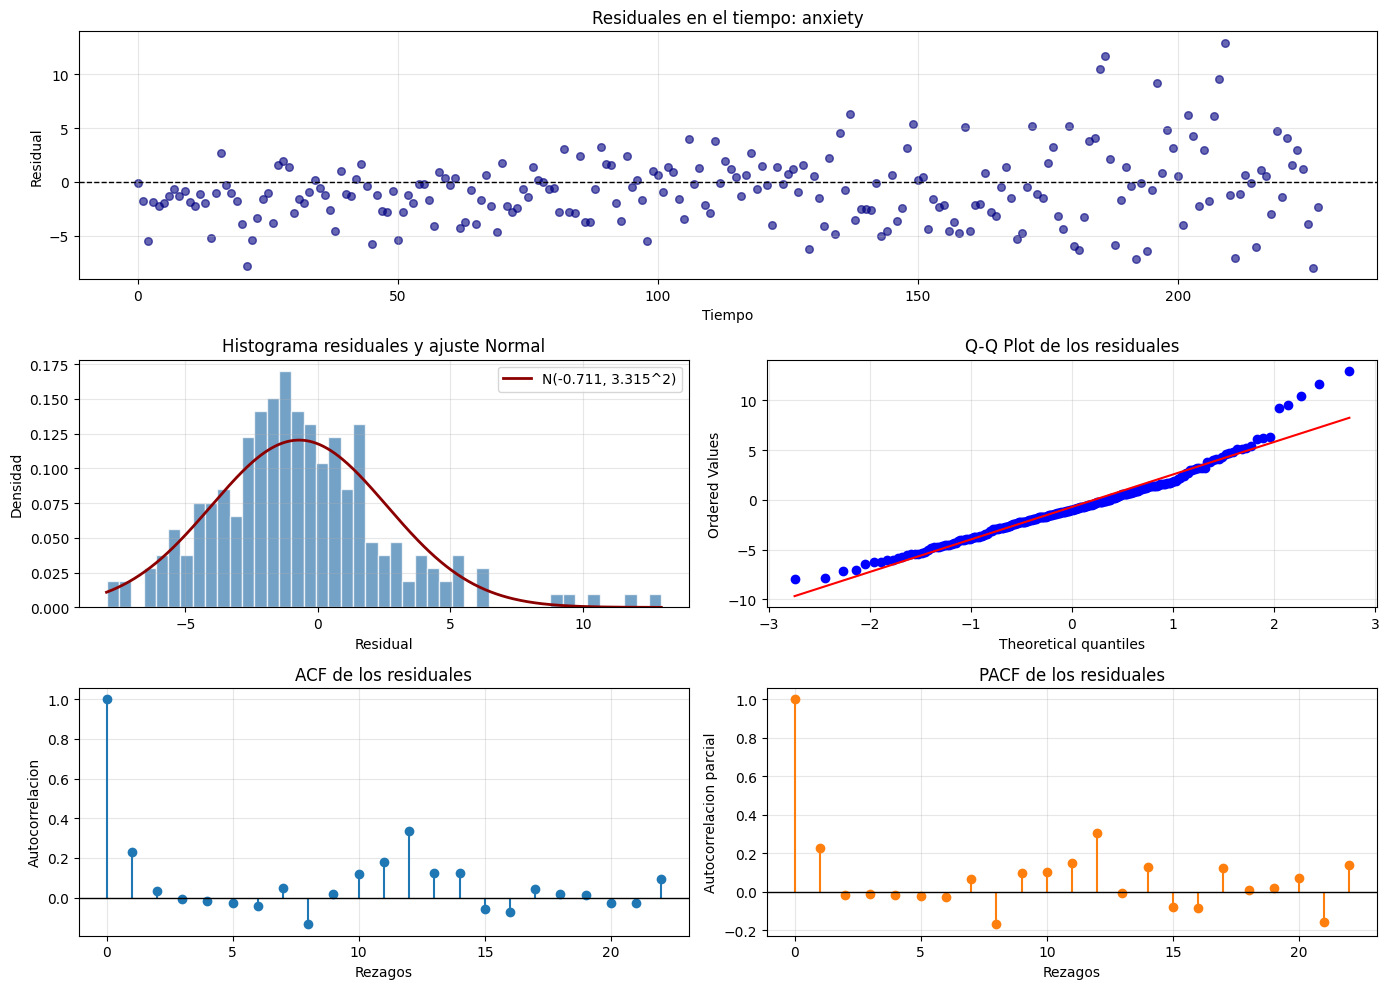

In [53]:
# Residuales y análisis (correctamente invertidos)
real_train = train_bc.iloc[lags:, 0].to_numpy().ravel()
real_train_inv = inv_boxcox(real_train, lambda_bc)  # Invertir Box-Cox completamente

pred_train = np.asarray(metricas_model1['y_train_pred_inv']).ravel()

n = min(len(real_train_inv), len(pred_train))
residuales = real_train_inv[:n] - pred_train[:n]

analisis_residuales(
    residuales,
    nombre="anxiety",
)

## Modelo 4 - CNN_LSTM

In [46]:
# Cargar modelo keras
from keras.models import load_model

model = load_model('modelo_4_CNN_LSTM_lags_8.keras')

# Creacion de lags (debe coincidir con el modelo cargado)
lags = 8
X_train, y_train = prepare_data_rnn(train_scaled, lags)
X_test, y_test = prepare_data_rnn(test_scaled, lags)

In [47]:
# Funciones de evaluacion y analisis para el modelo cargado
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import probplot, norm

def evaluar_modelo_ts(model, X_train, y_train, X_test, y_test, train_index, test_index, lags, scaler=None, transformacion=None, lambda_bc=None, nombre_modelo="Modelo", nombre_serie="Serie"):
    def invertir(valores):
        resultado = np.asarray(valores).reshape(-1, 1)
        if scaler is not None:
            resultado = scaler.inverse_transform(resultado)
        resultado = resultado.flatten()
        if transformacion == "log":
            resultado = np.exp(resultado)
        elif transformacion == "boxcox":
            if lambda_bc is None:
                raise ValueError("Se requiere lambda_bc para invertir Box-Cox.")
            resultado = inv_boxcox(resultado, lambda_bc)
        return resultado

    y_train_pred = model.predict(X_train, verbose=0).flatten()
    y_test_pred = model.predict(X_test, verbose=0).flatten()

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    y_train_inv = invertir(y_train)
    y_test_inv = invertir(y_test)
    y_train_pred_inv = invertir(y_train_pred)
    y_test_pred_inv = invertir(y_test_pred)

    rmse_train_inv = np.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
    rmse_test_inv = np.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
    mae_train_inv = mean_absolute_error(y_train_inv, y_train_pred_inv)
    mae_test_inv = mean_absolute_error(y_test_inv, y_test_pred_inv)
    r2_train_inv = r2_score(y_train_inv, y_train_pred_inv)
    r2_test_inv = r2_score(y_test_inv, y_test_pred_inv)

    print("═" * 62)
    print(f"  {nombre_modelo} | {nombre_serie}")
    print("═" * 62)
    print("\n  ▸ Espacio escalado/transformado:")
    print("    Métrica             Train         Test")
    print("    ────────────────────────────────────")
    print(f"    RMSE           {rmse_train:10.6f}  {rmse_test:12.6f}")
    print(f"    MAE            {mae_train:10.6f}  {mae_test:12.6f}")
    print(f"    R²             {r2_train:10.6f}  {r2_test:12.6f}")

    print("\n  ▸ Escala original:")
    print("    Métrica             Train         Test")
    print("    ────────────────────────────────────")
    print(f"    RMSE           {rmse_train_inv:10.4f}  {rmse_test_inv:12.4f}")
    print(f"    MAE            {mae_train_inv:10.4f}  {mae_test_inv:12.4f}")
    print(f"    R²             {r2_train_inv:10.6f}  {r2_test_inv:12.6f}")
    print("═" * 62)

    return {
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "mae_train": mae_train,
        "mae_test": mae_test,
        "r2_train": r2_train,
        "r2_test": r2_test,
        "rmse_train_original": rmse_train_inv,
        "rmse_test_original": rmse_test_inv,
        "mae_train_original": mae_train_inv,
        "mae_test_original": mae_test_inv,
        "r2_train_original": r2_train_inv,
        "r2_test_original": r2_test_inv,
        "y_train_pred": y_train_pred,
        "y_test_pred": y_test_pred,
        "y_train_pred_inv": y_train_pred_inv,
        "y_test_pred_inv": y_test_pred_inv,
        "train_index": train_index[lags:],
        "test_index": test_index[lags:],
    }


def analisis_residuales(residuales, nombre="Serie"):
    residuales = np.asarray(residuales).reshape(-1)
    residuales = pd.Series(residuales).dropna().astype(float)

    def acf_manual(values, max_lags):
        centered = values - values.mean()
        acf_vals = [1.0]
        for lag in range(1, max_lags + 1):
            x1 = centered[:-lag]
            x2 = centered[lag:]
            denom = np.sqrt(np.sum(x1 ** 2) * np.sum(x2 ** 2))
            acf_vals.append(float(np.sum(x1 * x2) / denom) if denom != 0 else 0.0)
        return np.array(acf_vals)

    def pacf_manual(values, max_lags):
        centered = values - values.mean()
        pacf_vals = [1.0]
        n_obs = len(centered)
        for lag in range(1, max_lags + 1):
            y_target = centered[lag:]
            x_matrix = np.column_stack([centered[lag - j - 1 : n_obs - j - 1] for j in range(lag)])
            x_matrix = np.column_stack([np.ones(len(y_target)), x_matrix])
            beta, *_ = np.linalg.lstsq(x_matrix, y_target, rcond=None)
            pacf_vals.append(float(beta[-1]))
        return np.array(pacf_vals)

    max_lags = min(25, max(1, len(residuales) // 10))
    acf_vals = acf_manual(residuales.values, max_lags)
    pacf_vals = pacf_manual(residuales.values, max_lags)

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 2)

    ax0 = fig.add_subplot(gs[0, :])
    ax0.scatter(residuales.index, residuales.values, color="navy", alpha=0.6, s=30)
    ax0.axhline(0, color="black", linestyle="--", linewidth=1)
    ax0.set_title(f"Residuales en el tiempo: {nombre}")
    ax0.set_xlabel("Tiempo")
    ax0.set_ylabel("Residual")
    ax0.grid(alpha=0.3)

    ax1 = fig.add_subplot(gs[1, 0])
    mu, sigma = residuales.mean(), residuales.std(ddof=1)
    ax1.hist(residuales.values, bins=45, density=True, color="steelblue", alpha=0.75, edgecolor="white")
    x_vals = np.linspace(residuales.min(), residuales.max(), 300)
    if sigma > 0:
        ax1.plot(x_vals, norm.pdf(x_vals, mu, sigma), color="darkred", linewidth=2, label=f"N({mu:.3f}, {sigma:.3f}^2)")
    ax1.set_title("Histograma residuales y ajuste Normal")
    ax1.set_xlabel("Residual")
    ax1.set_ylabel("Densidad")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[1, 1])
    probplot(residuales.values, dist="norm", plot=ax2)
    ax2.set_title("Q-Q Plot de los residuales")
    ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[2, 0])
    ax3.stem(range(len(acf_vals)), acf_vals, basefmt=" ", linefmt="C0-", markerfmt="C0o")
    ax3.axhline(0, color="black", linewidth=1)
    ax3.set_title("ACF de los residuales")
    ax3.set_xlabel("Rezagos")
    ax3.set_ylabel("Autocorrelacion")
    ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[2, 1])
    ax4.stem(range(len(pacf_vals)), pacf_vals, basefmt=" ", linefmt="C1-", markerfmt="C1o")
    ax4.axhline(0, color="black", linewidth=1)
    ax4.set_title("PACF de los residuales")
    ax4.set_xlabel("Rezagos")
    ax4.set_ylabel("Autocorrelacion parcial")
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [48]:
# Evaluacion del modelo
metricas_model4 = evaluar_modelo_ts(
    model=model,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    train_index=train_bc.index,
    test_index=test_bc.index,
    lags=lags,
    scaler=scaler,
    transformacion="boxcox",   # <-- esto es clave
    lambda_bc=lambda_bc,       # <-- esto también
    nombre_modelo="CNN-LSTM - Mejor Modelo",
    nombre_serie="anxiety",
)

metricas_model4

══════════════════════════════════════════════════════════════
  CNN-LSTM - Mejor Modelo | anxiety
══════════════════════════════════════════════════════════════

  ▸ Espacio escalado/transformado:
    Métrica             Train         Test
    ────────────────────────────────────
    RMSE             0.054314      0.039255
    MAE              0.042273      0.032496
    R²               0.958869      0.170808

  ▸ Escala original:
    Métrica             Train         Test
    ────────────────────────────────────
    RMSE               3.5364        3.7802
    MAE                2.5739        3.1554
    R²               0.958356      0.179094
══════════════════════════════════════════════════════════════


{'rmse_train': 0.05431383999732513,
 'rmse_test': 0.03925544366795638,
 'mae_train': 0.042273282182952676,
 'mae_test': 0.032495736479757585,
 'r2_train': 0.9588693208241614,
 'r2_test': 0.17080761124451127,
 'rmse_train_original': 3.536440441608916,
 'rmse_test_original': 3.7801690330830544,
 'mae_train_original': 2.5738535809652743,
 'mae_test_original': 3.1553698088151325,
 'r2_train_original': 0.958356040688765,
 'r2_test_original': 0.17909393242464378,
 'y_train_pred': array([0.41082305, 0.4146957 , 0.38755247, 0.37001082, 0.3697757 ,
        0.360817  , 0.3562907 , 0.34133786, 0.33838066, 0.32280946,
        0.3226336 , 0.30243897, 0.29897517, 0.28829107, 0.27749914,
        0.26664042, 0.31481224, 0.3122381 , 0.31274953, 0.28736398,
        0.29411322, 0.2608942 , 0.2414595 , 0.20858838, 0.18245456,
        0.14175363, 0.13980675, 0.14854833, 0.18698828, 0.19281705,
        0.20681743, 0.19561955, 0.20214248, 0.18552558, 0.1808148 ,
        0.15662369, 0.15914007, 0.15341893, 0.

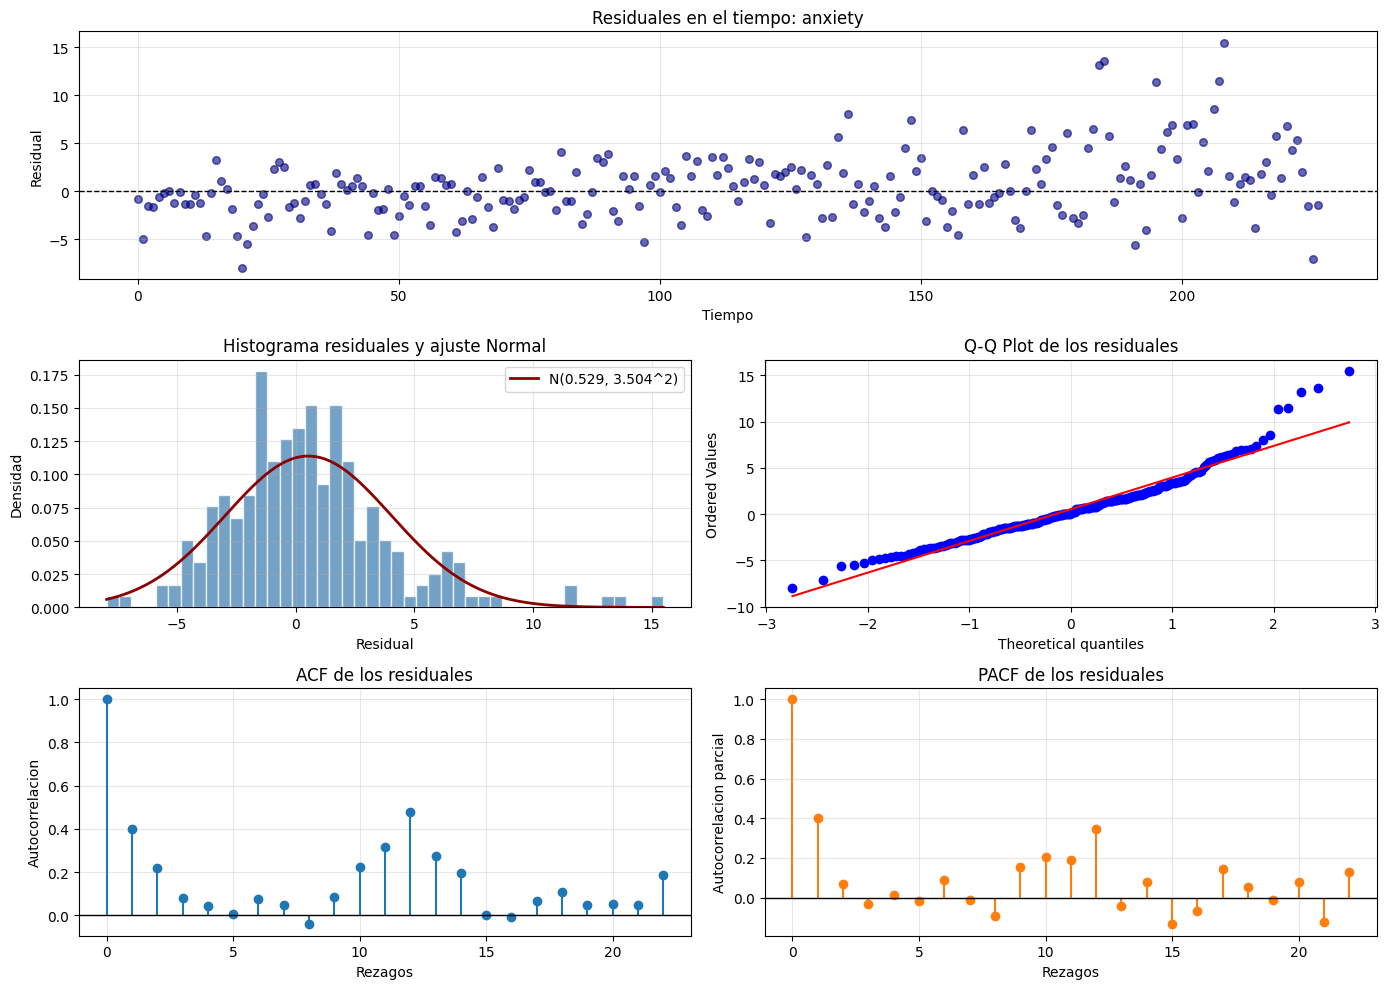

In [49]:
# Residuales y análisis (correctamente invertidos)
real_train = train_bc.iloc[lags:, 0].to_numpy().ravel()
real_train_inv = inv_boxcox(real_train, lambda_bc)  # Invertir Box-Cox completamente

pred_train = np.asarray(metricas_model4['y_train_pred_inv']).ravel()

n = min(len(real_train_inv), len(pred_train))
residuales = real_train_inv[:n] - pred_train[:n]

analisis_residuales(
    residuales,
    nombre="anxiety",
)